## Validation of the Medication Burden Index (MBI) for Identifying Hemodynamic Discordance in Resource-Limited Valvular Heart Disease Screening

## **1. Abstract**

* **Background:** High-volume cardiac missions often prioritize immediate intervention triage over comprehensive documentation, leading to selective data reporting. This necessitates objective proxies to quantify clinical risk when primary diagnostic data is streamlined.  

* **Objective:** To validate the Medication Burden Index (MBI)—a feature-engineered score of pharmacological intensity—as a triage tool for identifying critical hemodynamic decompensation and phenotypic complexity in valvular heart disease.  

* **Methods:** We performed a retrospective diagnostic accuracy study on a consecutive cohort from León, Nicaragua ($N=152$). The MBI was validated against transthoracic echocardiography (RVSP) using ROC analysis and linear regression to define triage zones.

* **Results:** The analysis established a Native Constant (baseline) of medication burden and identified an optimal MBI threshold of 5.25 for predicting critical pulmonary hypertension ($RVSP > 60$ mmHg) with high precision.    

* **Conclusions:** The MBI serves as a robust, reproducible proxy for clinical complexity. By anchoring pharmacological effort to anatomical reality, it provides a reliable safety net for surgical prioritization in resource-limited, high-throughput settings.  

---

## **2. Clinical Analytics Engine**  

This section contains the Python classes and medical configurations required to run the analysis.

In [2]:
# 1. IMPORTS
# ==========================================

# %matplotlib inline
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, HTML
import re
import missingno as msno
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score, confusion_matrix
from scipy.stats import kruskal, chi2_contingency
import scipy.stats as sstats
import scikit_posthocs as sp
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import os


In [3]:
# 2. DICTIONARIES AND LISTS
# ==========================================

# * These dictionaries and lists act as the "Medical Brain" of the script. 

# We separate logic from data to allow non-coders to update clinical criteria easily.
class ClinicalConfig:
    """
    Centralized configuration object acting as the 'Medical Brain'.
    Encapsulates all clinical dictionaries, regex patterns, decision boundaries,
    and biological sanity checks.
    """
    def __init__(self):
        # 1. We categorize variables to be selected for the dataframe
        self.categories = {
            "Demographics/Vitals": ['ID', 'Age', 'Gender', 'Weight', 'OSat', 'SBP R', 'DBP R', 'Heart rate'],
            "Medications": ['Medications'],
            "Clinical Context": ['Pre-procedure diagnosis', 'Post-procedure diagnosis', 'Year(s) since procedure'],
            "Structural Echo (Dimensions)": ['IVSd', 'LVIDd', 'LVPWd', 'LVIDs', 'Aortic root', 'Left atrium measure', 'Left atrium'],
            "Functional Echo (Hemodynamics)": ['LVEF (categorical)', 'RVSP', 'TR Vmax', 'AO V1 max', 'AO V2 max', 'MS MG (mmHg)']
        }

        # 2. Severity & Scoring Maps
        # Valve disease
        self.severity = {
            'critical': 3.5, 'severe to critical': 3.25, 'severe': 3.0,
            'moderate to severe': 2.5, 'moderate': 2.0, 'mild to moderate': 1.5,
            'mild': 1.0, 'none': 0.0
        }

        # LVEF
        self.lvef_values = {
            'Hyperdynamic': 70.0, 'Normal': 60.0, 'Borderline': 50.0,
            'Moderately reduced': 40.0, 'Reduced': 25.0
        }
        
        self.echo_severity = {'trace': 15.0, 'mild': 20.0, 'none': 10.0}

        # 3. Pattern Recognition (Regex Targets)
        # Procedures
        self.procedures = {
            "Surgical" : ['replacement', 'repair', 'patch', 'graft'],
            "Percutaneous" : ['percutaneous valvuloplasty', 'closure', 'stent', 'ablation']
        }

        # Diagnoses
        self.pathology_patterns = {
            'MS': ['mitral stenosis'],
            'MR': ['mitral regurgitation'],
            'AS':  ['aortic stenosis'],
            'AR': ['aortic regurgitation'],
            'PH': ['pulmonary hypertension'],
            'Septal': ['Secundum atrial septal defect', 'Perimembranous ventricular septal defect', 
                       'Ventricular septal defect', 'Incomplete atrioventricular septal defect', 'Sinus venosus atrial septal defect']
        }
        
        # LA size
        self.la_patterns = {
            4.0: r'(?:huge|severely|severe)',
            2.5: r'(?:moderately|moderate)',
            1.0: r'(?:mild)'
        }

        # 4. Pharmacological Knowledge Base
        # Medication classes
        self.medication_classes = {
            'Beta_Blockers': ['Carvedilol', 'Bisoprolol', 'Propranolol', 'Metoprolol', 'Atenolol'],
            'RAAS_Inhibitors': ['Enalapril', 'Lisinopril', 'Losartan', 'Valsartan', 'Irbesartan', 'Captopril', 'Sacubitril-valsartan'],
            'Diuretics_Loop': ['Furosemide'],
            'Diuretics_Other': ['Spironolactone', 'Espironolactone', 'Hydrochlorothiazide'],
            'Anticoagulants_Antiplatelets': ['Warfarin', 'Warfarine', 'Rivaroxaban', 'Apixaban', 'Aspirin', 'Clopidogrel'],
            'Rate_Rhythm_Control': ['Digoxin', 'Amiodarone'],
            'Calcium_Channel_Blockers': ['Nifedipine', 'Amlodipine'],
            'SGLT2_Inhibitors': ['Dapaglifozin', 'Empaglifozin'],
            'Pulmonary_Vasodilators': ['Sildenafil', 'Tadalafil'],
            'Lipid_Lowering': ['Simvastatin', 'Rosuvastatin', 'Rosuvastatine', 'Gemfibrozil', 'Ciprofibrate'],
            'Anti_Ischemic_Other': ['Trimetazidine', 'Ranolazine'],
            'Metabolic_Endocrine': ['Levothyroxine', 'Metformin']
        }

        # Prescription frequency per day
        self.freq_day = {'qd': 1, 'bid': 2, 'tid': 3, 'qid': 4}

        # Maximum doses per medication
        self.max_doses = {
            'Sacubitril-valsartan': 400.0, 'Enalapril': 40.0, 'Lisinopril': 40.0, 'Losartan': 100.0,
            'Valsartan': 320.0, 'Irbesartan': 300.0, 'Captopril': 150.0, 'Carvedilol': 50.0,
            'Bisoprolol': 10.0, 'Metoprolol': 200.0, 'Atenolol': 100.0, 'Propranolol': 160.0,
            'Furosemide': 80.0, 'Spironolactone': 50.0, 'Hydrochlorothiazide': 25.0,
            'Sildenafil': 60.0, 'Tadalafil': 40.0, 'Digoxin': 0.25, 'Amiodarone': 400.0,
            'Warfarin': 5.0, 'Rivaroxaban': 20.0, 'Apixaban': 10.0, 'Aspirin': 100.0,
            'Clopidogrel': 75.0, 'Nifedipine': 90.0, 'Amlodipine': 10.0, 'Trimetazidine': 70.0,
            'Ranolazine': 1000.0, 'Dapaglifozin': 10.0, 'Empaglifozin': 25.0, 'Metformin': 2000.0,
            'Levothyroxine': 0.2, 'Simvastatin': 40.0, 'Rosuvastatin': 40.0, 'Gemfibrozil': 1200.0,
            'Ciprofibrate': 100.0
        }

        # Class weights based on their clinical conditions they target
        self.class_weights = {
            'Diuretics_Loop': 3.0, 'Pulmonary_Vasodilators': 3.0, 'RAAS_Inhibitors': 2.0,
            'SGLT2_Inhibitors': 2.0, 'Diuretics_Other': 2.0, 'Beta_Blockers': 2.0,
            'Rate_Rhythm_Control': 1.0, 'Anticoagulants_Antiplatelets': 1.0,
            'Calcium_Channel_Blockers': 1.0, 'Anti_Ischemic_Other': 1.0,
            'Lipid_Lowering': 0.5, 'Metabolic_Endocrine': 0.5
        }

        # 5. Echo grouping by anatomic structures
        # Aortic, mitral or PH
        self.echo_groups = {
            "Mitral": {"Parameters": ['MS MG (mmHg)', 'Left atrium', 'LVIDd', 'LVIDs'], "Severity_Cols": ['Sev_MS', 'Sev_MR']},
            "Aortic": {"Parameters": ['AO V1 max', 'AO V2 max', 'Aortic root', 'IVSd', 'LVPWd'], "Severity_Cols": ['Sev_AS', 'Sev_AR']},
            "PH": {"Parameters": ['RVSP', 'TR Vmax'], "Severity_Cols": ['Sev_PH']}
        }

        # 6. Statistical Baselines for imputation
        # Normal distribution for the MNARs
        self.normal_variables = {
            'MS MG (mmHg)': (1.5, 0.5),
            'AO V2 max': (1.1, 0.2),
            'RVSP': (25.0, 4.0),
            'LVIDd': (4.6, 0.4)
        }

        # 7. Lists to be used as variables for the classes
        self.echo_vars = ['MS MG (mmHg)', 'AO V2 max', 'RVSP', 'Left atrium', 'LVIDd', 'LVEF (categorical)']
        self.echo_missing = ['MS MG (mmHg)', 'AO V2 max', 'RVSP', 'LVIDd']
        self.clinical_markers = ['Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'PH_Significant', 'AFib_Present']
        self.lesions_anatomic = ['Sev_MS','Sev_MR','Sev_AS','Sev_AR', 'Sev_PH']

        # 8. Empty lists to be used for regression
        self.regression_demographics = []
        self.regression_lesions = []
        self.regression_echo = []

In [ ]:
# 3. CLASSES AND FUNCTIONS
# ==========================================

class Auditor:
    """
    Acts as the 'Quality Control' station. 
    Before any analysis, we must identify 'Missing Not At Random' (MNAR) patterns 
    often caused by limited time during medical brigades.
    """
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def report(self):
        """
        Generates a 3-part audit: 
        1. Technical metadata.
        2. Clinical category missingness (shows which exam parts were skipped).
        3. Lexicon extraction (identifies unique raw strings for manual review).
        """
        audit = []
        for col in self.df.columns:
            audit.append({
                'Column': col,
                'Inferred dtype': self.df[col].dtype,
                'Null Count': self.df[col].isnull().sum(),
                'Sample Values': self.df[col].dropna().unique()[:3].tolist()
            })
            
        # Clinical NLP: Extracting the vocabulary used by doctors in the field.
        all_diagnoses = pd.concat([
            self.df['Pre-procedure diagnosis'],
            self.df['Post-procedure diagnosis']
        ]).str.split(',').explode().str.strip().dropna().unique()

        all_medications = self.df['Medications'].str.split('|').explode().str.strip().dropna()
        medications_unique = all_medications.str.split(' ').str[0].str.capitalize().unique()

        # Reporting Missingness by Clinical Grouping
        print(f"Current columns by category:\n{'-'*40}")
        for category, cols in self.config.categories.items():
            print(f"{category}: {cols}")

        group_report = {}
        missing_from_categories = []

        for group, cols in self.config.categories.items():
            # Checks if our expected columns actually exist in the CSV header
            not_found = [c for c in cols if c not in self.df.columns]
            found = [c for c in cols if c in self.df.columns]

            # This logs missing columns
            if not_found:
                missing_from_categories.extend(not_found)
                print(f"\nWarning in {group}: Missing from CSV: {not_found}")
                
            # This calculates mean missingness for found columns
            if found:
                avg_miss = self.df[found].isnull().mean().mean() * 100
                group_report[group] = f"{avg_miss:.2f}% missing"
            else:
                group_report[group] = "N/A - No columns found"

        print("\nMean missingness by category (%):")
        print(f"{'-'*40}")
        print(pd.Series(group_report))

        # Persistence: Ensuring we have an 'Audit Trail' for clinical accountability.
        audit_df = pd.DataFrame(audit)
        pd.DataFrame({'All_diagnoses_list': all_diagnoses}).to_csv('all_diagnoses_report.csv', index=False)
        pd.DataFrame({'All_medications_list': medications_unique}).to_csv('all_medications_report.csv', index=False)
        audit_df.to_csv('dataset_audit_report.csv', index=False)

        print('\nAudit report generated:\n' + f"{'-'*40}")
        print('Technical metadata file generated: dataset_audit_report.csv. ')
        print('All unique diagnoses list generated: all_diagnoses_report.csv.')
        print('All medications list generated: all_medications_report.csv.')
        return audit_df
        
    def echo_missingness(self):
        """
        Forensic Data Audit: 
        Calculates completion rates (%) per column, stratified by 
        disease severity and clinical grouping.
        """
        results = []
        
        # Access the injected echo_groups_dict
        for unit, groups in self.config.echo_groups.items():
            for sev_col in groups["Severity_Cols"]: 
                if sev_col not in self.df.columns:
                    continue
                
                for sev_level in sorted(self.df[sev_col].unique()):
                    subset = self.df[self.df[sev_col] == sev_level]
                    if subset.empty: continue
                    
                    for param in groups["Parameters"]:
                        if param in self.df.columns:
                            completeness = (1 - subset[param].isnull().mean()) * 100
                            results.append({
                                'Pathology': sev_col.replace('Sev_', ''),
                                'Severity': sev_level,
                                'Parameter': param,
                                'Completeness_Pct': round(completeness, 2),
                                'N': len(subset)
                            })
                            
        missings_stratified = pd.DataFrame(results)

        # Pivot for 'Missingness Matrix' visualization. 
        pivot_audit = missings_stratified.pivot_table(
            index=['Pathology', 'Parameter'], 
            columns='Severity', 
            values='Completeness_Pct' 
        )
        return pivot_audit

class Extractor:
    """
    The 'Refinery'. Transforms messy clinical strings into 'Tidy' structured data.
    Key philosophy: Do not oversimplify. Preserve mixed valvular disease signatures.
    """
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
        self.severities = list(self.config.severity.keys())
        # Regex to strip intensity
        self.strip_pattern = r'\b(' + '|'.join(self.severities) + r')\b'

    def _get_expanded_diag(self, col_name):
        """
        Handles comma-separated lists in a single cell.
        """
        return self.df[col_name].str.lower().str.split(',').explode().str.strip().dropna()

    def _clean_column(self, col):
        """
        Standardizes anatomy by removing qualitative noise and surgical terms.
        """
        s = self._get_expanded_diag(col)
        cleaned = s.str.replace(self.strip_pattern, '', regex=True) \
            .str.replace(r'\s+', ' ', regex=True) \
            .str.strip() \
            .str.capitalize()
        
        # Group back to original rows to maintain 1:1 patient mapping.
        return cleaned.groupby(level=0).agg(lambda x: ', '.join(x.unique()) if x.any() else np.nan)

    def _parse_meds(self, med_string, drug_list):
        """
        Pharmacological Parser:
        Identifies drug, extracts base dose, and applies frequency multipliers (e.g., bid=x2).
        """
        if pd.isna(med_string) or med_string == "":
            return "None", 0.0
            
        individual_meds = [m.strip().lower() for m in str(med_string).split('|')]
        
        for med_entry in individual_meds:
            matched_drug = next((d for d in drug_list if d.lower() in med_entry), None)
            
            if matched_drug:
                # Searches for match medications
                dose_match = re.search(r'(\d+\.?\d*)', med_entry)
                # Normalizes the medication intensity based on the max recommended dose
                base_dose = float(dose_match.group(1)) if dose_match else 0.0
                
                # Determine frequency multiplier
                multiplier = 1 
                for freq, value in self.config.freq_day.items():
                    if f" {freq}" in f" {med_entry}":
                        multiplier = value
                        break
                
                return matched_drug.capitalize(), base_dose * multiplier
                
        return "None", 0.0

    def transform(self):
        """
        Main orchestration of the feature engineering process.
        Creates a multidimensional lesion matrix (e.g., separate columns for MS and MR severity).
        """
        # 1. Anatomy Extraction (The 'What' is involved)
        self.df['Anatomy_Pre'] = self._clean_column('Pre-procedure diagnosis')
        self.df['Anatomy_Post'] = self._clean_column('Post-procedure diagnosis')

        # 2. Multidimensional Severity Mapping (The 'How Bad' is it?)
        def severity_score(text_series, path_regex):
            entries = str(text_series).lower().split(',')
            for entry in entries:
                if re.search(path_regex, entry):
                    for label, score in self.config.severity.items():
                        if label in entry: return score
            return 0.0

        # 3. Normalizes the severities per most relevant diagnoses
        for lesion, keywords in self.config.pathology_patterns.items():
            col_name = f'Sev_{lesion}'
            pattern = '|'.join(keywords) 
            self.df[col_name] = self.df['Pre-procedure diagnosis'].fillna('').apply(
                lambda x: severity_score(x, pattern)
            )

        # 4. Procedural Classification (The 'Approach')
        self.df['Approach'] = 'Native'
        post_exploded = self._get_expanded_diag('Post-procedure diagnosis')
        
        for group, keywords in self.config.procedures.items():
            pattern = '|'.join(keywords)
            idx = post_exploded[post_exploded.str.contains(pattern, regex=True, na=False)].index
            self.df.loc[idx, 'Approach'] = group

        # 5. Pharmacological Quantification
        for category, drugs in self.config.medication_classes.items():
            name_col = f"{category}_name"
            dose_col = f"{category}_tdd"
            
            # Use the internal _parse_meds method with injected freq_day
            self.df[[name_col, dose_col]] = self.df['Medications'].apply(
                lambda x: pd.Series(self._parse_meds(x, drugs))
            )

        # 6. Left Atrium Size Scoring
        self.df['LA_Size_Score'] = 0.0
        self.df['LA_Thrombus'] = 0.0
        self.df['LA_Mass'] = 0.0
        
        for score, pattern in self.config.la_patterns.items():
            # Only update if current score is lower (preserves the highest severity found)
            mask = self.df['Left atrium'].str.contains(pattern, case=False, na=False, regex=True)
            self.df.loc[mask, 'LA_Size_Score'] = np.maximum(self.df.loc[mask, 'LA_Size_Score'], score)

        # 7. Pathological Findings (Flags)
        # Thrombus/Clot/Smoke
        self.df['LA_Thrombus'] = self.df['Left atrium'].str.contains(r'(?:thrombus)', case=False, na=False, regex=True).astype(int)

        # Masses (Myxomas)
        self.df['LA_Mass'] = self.df['Left atrium'].str.contains(r'(?:myxoma)', case=False, na=False, regex=True).astype(int)
        
        # 8. Normalization of echo 
        for col in self.config.echo_missing:
            if col in self.df.columns:
                # Convert to string and handle whitespace
                # We use .str.strip() to catch hidden spaces like " 25 "
                s = self.df[col].astype(str).str.lower().str.strip()
                
                # Replace qualitative terms (trace, mild) with your dictionary
                s = s.replace(self.config.echo_severity)
                
                # Final Coercion
                # If a value was "45mm", pd.to_numeric turns it to NaN. 
                # If your data has "mm" in it, we must strip it first.
                s = s.str.extract(r'(\d+\.?\d*)')[0] # Remove all non-numeric chars
                
                self.df[col] = pd.to_numeric(s, errors='coerce').round(1)

        # 9. LVEF Numerical Mapping
        # We use .str.title() to match 'Normal', 'Reduced', etc. 
        if 'LVEF (categorical)' in self.df.columns:
            self.df['LVEF_Score'] = self.df['LVEF (categorical)'].str.strip().str.title().map(self.config.lvef_values)
            
            # Clinical Safety Check: If "Moderately reduced" has a lowercase 'r', 
            # title() makes it "Moderately Reduced". We adjust the map or use a lambda.
            self.df['LVEF_Score'] = self.df['LVEF (categorical)'].str.strip().map(
                {k: v for k, v in self.config.lvef_values.items()} # Direct map
            ).fillna(self.df['LVEF (categorical)'].str.strip().str.capitalize().map(self.config.lvef_values))
            
        return self.df

    def baseline(self):
        """
        Generates a Table of demographics and vitals.
        Calculates Mean ± SD for continuous and N (%) for categorical.
        """
        stats = []
        vitals = self.config.categories.get("Demographics/Vitals", [])

        print("Baseline characteristics\n" + '-'*40)

        for col in vitals:
            if col in self.df.columns:
                # Handles numeric columns (Age, Weight, Vitals)
                if pd.api.types.is_numeric_dtype(self.df[col]):
                    mean_val = self.df[col].mean()
                    std_val = self.df[col].std()
                    null_pct = self.df[col].isnull().mean() * 100
                    stats.append({
                        "Characteristic": col,
                        "Value": f"{mean_val:.1f} ± {std_val:.1f}",
                        "Completeness": f"{100 - null_pct:.1f}%",
                        "Type": "Continuous"
                    })
                # Handles categorical (Gender)
                else:
                    top_val = self.df[col].mode()[0] if not self.df[col].mode().empty else "N/A"
                    count = (self.df[col] == top_val).sum()
                    pct = (count / len(self.df)) * 100
                    stats.append({
                        "Characteristic": col,
                        "Value": f"Mode: {top_val} ({pct:.1f}%)",
                        "Completeness": f"{100 - (self.df[col].isnull().mean()*100):.1f}%",
                        "Type": "Categorical"
                    })
                
        return display(pd.DataFrame(stats).set_index("Characteristic"))

    def diagnoses_prevalence(self):
        """
        Standardizes and counts the global disease burden in the cohort.
        """
        # Note: transform() must be called before this method to generate Anatomy_Pre
        if 'Anatomy_Pre' not in self.df.columns:
             raise ValueError("Please run transform() first.")
        
        pre = self.df['Anatomy_Pre'].str.split(', ').explode()
        post = self.df['Anatomy_Post'].str.split(', ').explode()
        
        # Combines them and remove 'nan' strings or empty entries
        combined = pd.concat([pre, post])
        combined = combined[~combined.isin(['nan', '', 'None', 'None, None'])]
        
        # Calculates Counts
        counts = combined.value_counts()
        
        # Creates the final Table
        prevalence_df = pd.DataFrame({
            'Patient Count': counts,
            'Prevalence (%)': (counts / len(self.df) * 100).round(1)
        })
        
        prevalence_df.index.name = 'Diagnosis'

        return prevalence_df

    def disease_profiler(self):
        '''
        Identifies complex interactions: Mixed Lesions, Shunts, and Rhythm Confounders.
        '''
        if 'Sev_MS' not in self.df.columns:
             raise ValueError("Please run transform() with required dictionaries before running disease_profiler()")

        # 1. Mixed Valvular Disease (Same-valve: Stenosis + Regurgitation)
        self.df['Mixed_Mitral'] = ((self.df['Sev_MS'] > 0) & (self.df['Sev_MR'] > 0)).astype(int)
        self.df['Mixed_Aortic'] = ((self.df['Sev_AS'] > 0) & (self.df['Sev_AR'] > 0)).astype(int)

        # 2. Multi-Valvular Disease (Cross-valve: Mitral unit AND Aortic unit)
        mitral_any = (self.df['Sev_MS'] > 0) | (self.df['Sev_MR'] > 0)
        aortic_any = (self.df['Sev_AS'] > 0) | (self.df['Sev_AR'] > 0)
        self.df['Multi_Valve'] = (mitral_any & aortic_any).astype(int)

        # 3. Pulmonary Hypertension
        # Defined here as any PH mention (Severity > 0)
        self.df['PH_Present'] = (self.df['Sev_PH'] > 0).astype(int)
        self.df['PH_Significant'] = (self.df['Sev_PH'] >= 2.0).astype(int)

        # 4. Septal Defects
        shunt_pattern = '|'.join(self.config.pathology_patterns['Septal'])
        self.df['Has_Shunt'] = self.df['Pre-procedure diagnosis'].str.contains(
            shunt_pattern, case=False, na=False, regex=True
        ).astype(int)

        # 5. Rhythm Confounders (AFib)
        self.df['AFib_Present'] = self.df['Pre-procedure diagnosis'].str.contains(
            'Atrial fibrillation', case=False, na=False, regex=True
        ).astype(int)

        # 6. Global Complexity Score 
        # Summing binary flags. Note: For PH, we only count it as a single 'Complexity Point' 
        # if it is Moderate or worse (>= 2.0), as Mild PH is very common.
        self.df['Complexity_Score'] = (
            self.df['Mixed_Mitral'] + 
            self.df['Mixed_Aortic'] + 
            self.df['Multi_Valve'] + 
            self.df['AFib_Present'] + 
            self.df['PH_Significant']
        )

        # Accurate Prevalence Reporting
        self.complexity_stats = {
            "Total Patients": len(self.df),
            "Mixed Mitral": self.df['Mixed_Mitral'].sum(),
            "Mixed Aortic": self.df['Mixed_Aortic'].sum(),
            "Multi-Valvular": self.df['Multi_Valve'].sum(),
            "Significant PH (>=2.0)": self.df['PH_Significant'].sum(),
            "AFib Present": self.df['AFib_Present'].sum()
        }
        
        return self.df
        
    def complexity_report(self):
        """
        Returns the stats as a clean Pandas Series for easy display or export.
        """
        print("Complex cases\n" + '-'*40)
        print("Cases that have either mixed, multiple valvular disease and/or other conditions\n")
        if hasattr(self, 'complexity_stats'):
            return pd.Series(self.complexity_stats, name="Prevalence")
        else:
            return "Profiler has not been run yet."

class Calculator:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def medication_index(self):
        """
        Computes the Medication Burden Index (MBI).
        MBI = Sum(Class_Weight * (Actual_TDD / Max_TDD))
        """
        self.df['MBI'] = 0.0
        
        for category, weight in self.config.class_weights.items():
            name_col = f"{category}_name"
            dose_col = f"{category}_tdd"
            
            if name_col in self.df.columns:
                # Vectorized calculation for each class
                # Uses 1.0 as a fallback intensity for fixed-dose meds (like Aspirin)
                intensity = self.df.apply(
                    lambda x: x[dose_col] / self.config.max_doses.get(x[name_col], x[dose_col]) 
                    if x[dose_col] > 0 else 0, axis=1
                )
                
                # Clips intensity at 1.0 (to avoid outliers from rare supra-therapeutic doses)
                self.df['MBI'] += (intensity.clip(upper=1.0) * weight)
                
        return self.df
    
class Visualizer:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
        plt.style.use('seaborn-v0_8-white') 
        sns.set_context("paper", font_scale=1.2)
        plt.rcParams['font.family'] = 'sans-serif' # JACC prefers clean sans-serif

    def patient_nullity(self):
        # Forensic Audit: Visualizing data deserts to evaluate mission-specific documentation constraints.
        available_keys = [v for v in self.config.echo_vars if v in self.df.columns]

        print("Missingness visualizations\n" + '-' *40)
        with plt.style.context('default'):
            plt.figure(figsize=(10, 6))
            msno.matrix(self.df[available_keys], 
                        sparkline=False, 
                        color=mcolors.to_rgb('#2c3e50'), # Your dark blue
                        fontsize=10)
            plt.title("Nullity Matrix: Data Presence (Dark) vs Missing (White)", fontsize=14)
            plt.show()

        print("Note: Correlation of Missingness (1.0 = Always missing together):")
        # Heatmap usually works better with a standard context too
        with plt.style.context('default'):
            msno.heatmap(self.df[available_keys], cmap='Blues')
            plt.title("Missingness Correlation")
            plt.show()

    def echo_matrix(self, table):
        # Triage Efficiency: Quantifying which physiological parameters are deemed 'Critical Path' by the field team.
        print("\nEchocardiogram Triage Matrix notes:" + "\n" + "-"*40)
        print("A 'Hot' cell (High %) indicates a parameter the cardiologist deemed mandatory for triage.")
        
        plt.figure(figsize=(14, 10))
        # Using a sequential colormap (YlOrRd) to highlight 'Data Deserts' vs 'Data Oases'.
        sns.heatmap(table.fillna(0), annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Completeness %'})
        plt.title("Echocardiogram Triage Matrix: Data Presence as a Function of Disease Severity", fontsize=15)
        plt.xlabel("Clinician-Assessed Severity (Ordinal Scale)")
        plt.ylabel("Echocardiographic Parameter by Pathology")
        plt.show()

    def complexity_frequency(self):
        """
        Visualizes the phenotypic burden of the cohort.
        """
        plt.figure(figsize=(10, 6))
        
        # Count frequencies of each score
        counts = self.df['Complexity_Score'].value_counts().sort_index()
        
        # Create a bar plot
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="GnBu", legend=False)
        
        plt.title("Distribution of Patient Complexity Scores", fontsize=15)
        plt.xlabel("Complexity Score (0 = Simple, 1+ = Highly Complex)", fontsize=12)
        plt.ylabel("Number of Patients", fontsize=12)
        
        # Add labels on top of bars
        for i, val in enumerate(counts.values):
            plt.text(i, val + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')
            
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    def complexity_markers(self):
        """
        Shows the prevalence of specific complexity markers.
        """
        prevalence = self.df[self.config.clinical_markers].sum().sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        prevalence.plot(kind='barh', color='#2c3e50')
        plt.title("Prevalence of Complexity Markers", fontsize=15)
        plt.xlabel("Patient Count", fontsize=12)
        plt.gca().invert_yaxis()
        plt.show()

    def complexity_heatmap(self):
        """
        Interaction Analysis: Identifying 'Syndromic Clusters' where multiple pathologies co-exist, 
        increasing clinical risk.
        """
        # Calculate the correlation (co-occurrence)
        # We use 'pearson' here to see how strongly one predicts the other
        interaction_matrix = self.df[self.config.clinical_markers].corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(interaction_matrix, annot=True, cmap='GnBu', center=0, fmt=".2f")
        
        plt.title("Clinical Interaction Heatmap: Pathological Clustering", fontsize=15)
        plt.tight_layout()
        plt.show()

    def sensitivity_grid(self):
        """
        Generates a 2x2 matrix of KDE plots comparing Measured vs. Imputed data.
        """
        # Identifies variables to plot
        plot_vars = [v for v in self.config.echo_missing if v in self.df.columns]
        
        # Creates the 2x2 figure (4 subplots)
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for i, var in enumerate(plot_vars):
            if i >= 4: break # Limit to 4x4 grid
            
            ax = axes[i]
            imp_col = f"{var}_Imputed"
            
            if imp_col in self.df.columns:
                # Measured Data (The "Sick" Triage Group)
                sns.kdeplot(self.df[var].dropna(), ax=ax, color='#08519c', fill=True, 
                            label='Measured', alpha=0.3)
                
                # Total Cohort (The "Natural Normal" Imputation)
                sns.kdeplot(self.df[imp_col], ax=ax, color='#969696', linestyle='--', 
                            label='Total Cohort')
                
                ax.set_title(f"{var}: Distribution Shift", fontsize=12, fontweight='bold')
                ax.set_xlabel("Value")
                ax.set_ylabel("Density")
                ax.legend(fontsize=8)
            else:
                ax.text(0.5, 0.5, f"No Data for {var}", ha='center')

        # Cleans up empty subplots if fewer than 4 variables exist
        for j in range(len(plot_vars), 4):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.suptitle("Clinical Sensitivity Matrix: Measured vs. Imputed Populations", 
                    fontsize=14, y=1.02)
        plt.show()

    def validate_vis(self, matrix, x_label, y_label, title):
        # Generates confusion matrix
        plt.figure(figsize=(8,6))
        sns.heatmap(matrix, annot=True, fmt='d', cmap='GnBu', 
                    xticklabels=['MBI Low', 'MBI High'], 
                    yticklabels=['Healthy', 'Complex'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        print("\nConfusion matrix visualization\n" + '-'*40)
        plt.show()

    def predictor_decomposition(self):
        """
        Generates an interactive horizontal stacked bar chart.
        Shows granular drug dominance and internal percentages.
        """
        composition_data = []

        # Calculation Logic (Parsed from Category/TDD structure)
        for category, weight in self.config.class_weights.items():
            name_col = f"{category}_name"
            dose_col = f"{category}_tdd"
            
            if name_col in self.df.columns and dose_col in self.df.columns:
                valid_rows = self.df[self.df[name_col] != "None"]
                max_doses = valid_rows[name_col].map(self.config.max_doses).fillna(0)
                intensities = (valid_rows[dose_col] / max_doses).clip(upper=1.0)
                burdens = intensities * weight
                
                drug_sums = burdens.groupby(valid_rows[name_col]).sum()
                category_total = drug_sums.sum()

                for drug, burden in drug_sums.items():
                    composition_data.append({
                        'Medication_Class': category,
                        'Specific_Drug': drug,
                        'Burden_Score': burden,
                        'Clinical_Weight': weight,
                        'Percentage_of_Class': (burden / category_total * 100) if category_total > 0 else 0
                    })

        df_comp = pd.DataFrame(composition_data)
        df_comp = df_comp.sort_values(['Clinical_Weight', 'Medication_Class'], ascending=[False, True])

        # Interactive Figure (Colored by Weight with Legend)
        fig = px.bar(
            df_comp, 
            y="Medication_Class", 
            x="Burden_Score", 
            color="Clinical_Weight",  # This creates the Weight-based Legend
            color_continuous_scale=px.colors.sequential.GnBu,
            # color_continuous_scale=[[0, '#bdc3c7'], [1, '#2c3e50']],
            orientation='h',
            title=f"Global MBI Architecture by Clinical Priority (n={len(self.df)})",
            hover_data={
                'Specific_Drug': True,
                'Percentage_of_Class': ':.1f',
                'Burden_Score': ':.2f',
                'Clinical_Weight': True,
                'Medication_Class': False 
            },
            labels={
                'Burden_Score': 'Weighted Burden Contribution',
                'Clinical_Weight': 'Medical Weight Tier'
            },
            template="plotly_white"
        )

        fig.update_layout(
            barmode='stack', 
            height=800,
            yaxis={'categoryorder': 'total ascending'},
            )
        
        print("Global MBI burden, stratified by medication classes\n" + '-'*40)
        display(Markdown("Bars represent **aggregate population burden**    \nColor indicate **clinical priority** weights"))
        fig.show()

        # Automated Key Findings Summary
        self._print_mbi_summary(df_comp)
        
        return df_comp
    
    def _print_mbi_summary(self, df_comp):
        total_mbi = df_comp['Burden_Score'].sum()
    
        # Get Top 3 Classes by total burden
        class_totals = df_comp.groupby('Medication_Class')['Burden_Score'].sum().sort_values(ascending=False).head(3)
        
        print(f"\n{'='*60}\nKEY MBI FINDINGS SUMMARY: PHARMACOLOGICAL DRIVERS\n{'='*60}")
        print(f"Total Cohort Burden Score: {total_mbi:.1f}")
        
        print(f"\nTOP 3 CLINICAL DRIVERS:")
        for i, (category, total) in enumerate(class_totals.items(), 1):
            # Identify the most used medication within this specific class
            class_meds = df_comp[df_comp['Medication_Class'] == category]
            dominant_med = class_meds.loc[class_meds['Burden_Score'].idxmax()]
            
            # Calculate class contribution to global MBI
            global_pct = (total / total_mbi) * 100
            
            print(f"{i}. {category:25} | Burden: {total:5.1f} ({global_pct:4.1f}%)")
            print(f"   - Dominant Medication: {dominant_med['Specific_Drug']} "
                f"({dominant_med['Percentage_of_Class']:.1f}% of class)")
        
        # Gap analysis
        gap_classes = df_comp[df_comp['Burden_Score'] == 0]['Medication_Class'].unique()
        if len(gap_classes) > 0:
            print(f"\nIdentified Care Gaps: No utilization in {len(gap_classes)} high-weight categories.")
        print(f"{'='*60}\n")

    def residual_distribution(self, results_df, y_var='MBI'):
        """
        UPDATED: Moved from violin plot to faceted histograms.
        Plots the error (Actual - Predicted) to identify where the model struggles.
        """
        res_col = f'{y_var}_Residual'
        
        if res_col not in results_df.columns:
            print(f"[!] Error: Column {res_col} not found in the provided DataFrame.")
            return

        # Faceted Histogram for Scientific Transparency
        g = sns.FacetGrid(results_df, col="Approach", hue="Approach", 
                          palette="Blues", height=4, aspect=1.2)
        
        g.map(sns.histplot, res_col, kde=True, element="step", alpha=0.5)
        
        # Formatting for a professional clinical report
        g.set_axis_labels(f"Residuals (Actual - Predicted {y_var})", "Patient Count")
        g.set_titles("Strata: {col_name}")
        
        for ax in g.axes.flatten():
            ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
            # Annotate regions
            ax.text(ax.get_xlim()[0]*0.9, ax.get_ylim()[1]*0.8, "Under-predicting", 
                    color='darkblue', fontsize=9, weight='bold')
            ax.text(ax.get_xlim()[1]*0.1, ax.get_ylim()[1]*0.8, "Over-predicting", 
                    color='darkred', fontsize=9, weight='bold')

        plt.subplots_adjust(top=0.85)
        g.fig.suptitle(f'Model Error Distribution: {y_var} Prediction Accuracy', fontsize=16)
        plt.show()

    def diagnostic_plots(self, results_df, y_var='MBI'):
        """
        THE SCIENTIFIC GOLD STANDARD: Histogram + Q-Q Plot.
        Proves that the model's errors follow a normal distribution,
        validating the use of p-values and linear assumptions.
        """
        res_col = f'{y_var}_Residual'
        if res_col not in results_df.columns:
            print(f"[!] Error: {res_col} not found.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # 1. Histogram with KDE
        sns.histplot(results_df[res_col], kde=True, ax=ax1, color='#08519c', bins=20)
        ax1.set_title(f'Residual Distribution: {y_var}', fontsize=14)
        ax1.set_xlabel('Error (Actual - Predicted)')
        
        # 2. Q-Q Plot (Normal Probability Plot)
        sstats.probplot(results_df[res_col], dist="norm", plot=ax2)
        ax2.get_lines()[0].set_markerfacecolor('#08519c')
        ax2.get_lines()[0].set_alpha(0.5)
        ax2.set_title('Normal Q-Q Plot', fontsize=14)
        
        plt.tight_layout()
        plt.show()

    def residual_vs_fitted(self, results_df, y_var='MBI'):
        """
        THE CLINICAL FAIRNESS CHECK: Residuals vs. Predicted Values.
        Checks if the model is 'biased' towards specific types of patients.
        """
        pred_col = f'{y_var}_Predicted'
        res_col = f'{y_var}_Residual'
        
        plt.figure(figsize=(10, 6))
        
        # We color by Approach or Zone to see if error clusters in a specific triage group
        sns.scatterplot(
            data=results_df, 
            x=pred_col, 
            y=res_col, 
            hue='Approach', # Or 'MBI_Zone' if available in results_df
            palette='Blues', 
            alpha=0.7, 
            s=80
        )
        
        # Horizontal line at 0 (Perfect Prediction)
        plt.axhline(0, color='red', linestyle='--', linewidth=2)
        
        plt.title(f'Residuals vs. Fitted Values ({y_var})', fontsize=15)
        plt.xlabel(f'Predicted {y_var} (Model Fit)', fontsize=12)
        plt.ylabel('Residual (Error)', fontsize=12)
        
        # Adding a 'Confidence Band' (Optional but professional)
        plt.fill_between(plt.xlim(), -1, 1, color='gray', alpha=0.1, label='Target Error Band')
        
        sns.despine()
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_flowchart(self):
        # Tightened figsize to reduce vertical margin
        fig, ax = plt.subplots(figsize=(10, 6)) 
        
        # Adjusting ylim from (0, 10) to (2, 10) crops the blank space at the bottom
        ax.set_xlim(0, 10); ax.set_ylim(2, 10); ax.axis('off')
        
        # Stylized Boxes
        box_main = dict(boxstyle='round,pad=0.6', facecolor='#eff9ff', edgecolor='#003152', linewidth=1.5)
        box_excl = dict(boxstyle='round,pad=0.5', facecolor='#fff0f0', edgecolor='#8b0000', linewidth=1)
        
        # 1. Enrollment
        ax.text(5, 9, "ENROLLMENT\nConsecutive Cardiac Brigade Cohort (Feb 2025)\n(N=187)", 
                ha='center', bbox=box_main, fontweight='bold')
        
        # 2. Exclusion
        ax.text(8.5, 7.5, "EXCLUDED (n=35)\n\n• Age < 15 (n=22)\n• Normal Findings (n=13)", 
                ha='left', va='center', bbox=box_excl, fontsize=9)
        
        # 3. Allocation
        ax.text(5, 6, "ALLOCATION\nStructural Heart Disease Analytical Sample\n(N=152)", 
                ha='center', bbox=box_main, fontweight='bold')
        
        # 4. The STARD Split (Verification)
        ax.text(2.5, 3.2, "INDEX TEST\nMedication Burden Index\n(n=152)", ha='center', bbox=box_main)
        ax.text(7.5, 3.2, "REFERENCE STANDARD\nTransthoracic Echo (RVSP)\n(n=152)", ha='center', bbox=box_main)
        
        # Arrows
        arrow = dict(arrowstyle='->', color='#003152', linewidth=1.5)
        ax.annotate('', xy=(5, 7.1), xytext=(5, 8.7), arrowprops=arrow)
        ax.annotate('', xy=(8.4, 7.5), xytext=(5, 7.5), arrowprops=arrow)
        ax.annotate('', xy=(2.5, 4.3), xytext=(5, 5.7), arrowprops=arrow) # To Index
        ax.annotate('', xy=(7.5, 4.3), xytext=(5, 5.7), arrowprops=arrow) # To Reference

        plt.title("2025 Cohort Participant Flow Diagram", fontsize=14, pad=10, color='#003152', fontweight='bold')
        
        # bbox_inches='tight' ensures no extra white space when saved or displayed
        plt.show()

class Statistics:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def impute_normal(self, target_col):
        """
        Implements 'Brigade Logic': Missing values are assumed normal, 
        but filled with Gaussian noise to preserve dataset variance.
        """
        temp_df = self.df.copy()
        temp_df[target_col] = pd.to_numeric(temp_df[target_col], errors='coerce')
        
        mask = temp_df[target_col].isnull()
        num_missing = mask.sum()
        
        mean, std = self.config.normal_variables.get(target_col, (0, 1))
        simulated_normals = np.random.normal(mean, std, size=num_missing).round(1)
        temp_df.loc[mask, target_col] = np.clip(simulated_normals, 0, 150)
                
        return temp_df[target_col]

    def apply_imputation(self):
        for var in self.config.echo_missing:
            if var in self.df.columns:
                # Use 'Natural Normal' to respect Brigade Logic while keeping variance
                self.df[f'{var}_Imputed'] = self.impute_normal(var)
                print(f"Handled {var} using 'Natural Normal' distribution.")

        return self.df
    
    def sensitivity_report(self):
        """
        Creates a succinct summary comparing Measured (Sick) vs. Imputed (Cohort) data.
        """
        summary_data = []
        
        # We only look at variables that were actually imputed
        for var in self.config.echo_missing:
            imp_col = f"{var}_Imputed"
            
            if var in self.df.columns and imp_col in self.df.columns:
                # Data for patients who actually had measurements (The "Red" group)
                measured = self.df[var].dropna()
                
                # Data for the whole cohort after imputation (The "Green" group)
                cohort = self.df[imp_col]
                
                if len(measured) > 0:
                    m_mean = measured.mean()
                    c_mean = cohort.mean()
                    delta = c_mean - m_mean
                    
                    # Clinical Interpretation Logic
                    # If the shift is more than 10% of the measured value, we flag it.
                    bias_status = "Significant Shift" if abs(delta) > (m_mean * 0.1) else "Stable"
                    
                    summary_data.append({
                        "Clinical Parameter": var,
                        "Measured Mean": round(m_mean, 1),
                        "Cohort Mean": round(c_mean, 1),
                        "Delta (Shift)": round(delta, 1),
                        "Triage Bias": bias_status,
                        "Sample Size (n)": len(measured)
                        })

        # Create DataFrame
        report_df = pd.DataFrame(summary_data).set_index("Clinical Parameter")
        return report_df
    
    def roc(self, predictor_col='MBI', target=None):
        """
        Generalized ROC analysis.
        Tests how well a chosen column (predictor_col) predicts Clinical Complexity.
        """
        # Ensures the column exists to avoid a KeyError
        if predictor_col not in self.df.columns:
            print(f"Error: {predictor_col} not found in dataframe.")
            return

        # 2. Dynamic Target Resolution
        if target is None:
            # Default logic: Capturing 'Rising Risk' (Score 1 or higher)
            y_true = (self.df['Complexity_Score'] > 0).astype(int)
            target_label = "Clinical Complexity"
        elif isinstance(target, str):
            # If a column name is passed
            y_true = self.df[target].astype(int)
            target_label = target
        else:
            # If a boolean mask/expression is passed (e.g. self.df['Sev_PH'] >= 3.0)
            y_true = target.astype(int)
            target_label = "Custom Clinical Threshold"

        # Recalculates ROC Metrics
        # We drop NAs for the specific predictor to prevent the roc_curve function from failing
        # temp_df = self.df[['Is_Complex_Case', predictor_col]].dropna()
        y_scores = self.df[predictor_col]

        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        # Finding the Optimal Cutoff using Youden's J statistic
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        best_cutoff = thresholds[best_idx]

        # Visualization
        print(f"ROC visualization for {predictor_col}\n" + '-'*40)
        plt.figure(figsize=(10, 7))
        plt.plot(fpr, tpr, color='#08519c', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='#bdbdbd', linestyle='--', label='Random Classifier')
        
        # Dynamic Label for the Scatter Point
        plt.scatter(fpr[best_idx], tpr[best_idx], color='black', s=100, zorder=5,
                    label=f'Optimal {predictor_col} Cutoff: {best_cutoff:.2f}')

        plt.xlabel('False Positive Rate (1 - Specificity)')
        plt.ylabel('True Positive Rate (Sensitivity)')
        
        # Dynamic Title
        plt.title(f'Predicting: {target_label} via {predictor_col}', fontsize=14)
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()

        print(f"Analysis Complete: A value of {predictor_col} above {best_cutoff:.2f} is the best predictor of patient complexity.\n")

    def validate_predictor(self, threshold):
        """
        Calculates the F1-Score to validate if MBI > 4.0 
        is a reliable proxy for Anatomical Complexity >= 2.0.
        """
        y_true = self.df['Is_Complex_Anatomic']
        y_pred = self.df['MBI_Predicted_High']
        
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        
        # Portfolio-ready output
        print(f"MBI Threshold Validation (> {threshold})\n" + '-'*40)
        print(f"F1-Score:  {f1:.3f}")
        print(f"Precision: {precision:.3f} (Reliability: When MBI is high, is the patient actually sick?)")
        print(f"Recall:    {recall:.3f} (Sensitivity: Does MBI catch all the sick patients?)")
        cm = confusion_matrix(y_true, y_pred)
        
        return cm 
    
    def _prepare_regression_features(self, df_to_fix):
        # We perform operations on the passed dataframe and return it
        df_to_fix['Gender_Male'] = (df_to_fix['Gender'].str.lower() == 'male').astype(int)
        df_to_fix['Mitral_Mixed_Score'] = df_to_fix['Sev_MS'] * df_to_fix['Sev_MR']
        df_to_fix['Aortic_Mixed_Score'] = df_to_fix['Sev_AS'] * df_to_fix['Sev_AR']
        return df_to_fix

    def run_regression(self, y_var, strata=None, excluded_features=None):
        """
        Modular engine to execute stratified regressions.
        :param y_var: The dependent variable (e.g., 'MBI' or 'RVSP_Imputed')
        :param feature_list: List of predictors to include
        :param strata: Specific 'Approach' to run (e.g., 'Native'). If None, loops all.
        """
        working_df = self.df.copy()

        # 1. Prepare features ONLY on the working copy
        working_df = self._prepare_regression_features(working_df)

        # 2. Ternary switch for strata list
        target_approaches = [strata] if strata else ['Native', 'Percutaneous', 'Surgical']

        # 3. Determine if we are doing a deep dive (single strata selected)
        is_deep_dive = len(target_approaches) == 1   
        
        # 4. Expand the feature list
        demographics = self.config.regression_demographics
        lesions = self.config.regression_lesions
        echo = self.config.regression_echo
        
        features = demographics + lesions + echo
        
        # 2. SILENCING LOGIC: Remove variables the user wants to ignore
        if excluded_features:
            features = [f for f in features if f not in excluded_features]

        # 5. Stratification Logic
        status_results = []
        all_subs = []
        for status in target_approaches:
            # Slices a deep copy for the specific cohort
            sub_df = working_df[working_df['Approach'] == status].copy()
            current_features = [f for f in features if f in self.df.columns and f != y_var]
            
            # Check if we have any features left to run!
            if not current_features:
                print(f"[!] No valid features found for {status}. Skipping.")
                continue

            # Isolate the group
            sub_df = sub_df.dropna(subset=current_features + [y_var])
            
            if len(sub_df) < 15: # Minimum threshold to avoid running on low statistical power
                print(f"\n[!] Stratum '{status}' skipped: Insufficient data (n={len(sub_df)})")
                continue
            
            # Fit Model
            X = sm.add_constant(sub_df[current_features])
            y = sub_df[y_var]
            model = sm.OLS(y, X).fit()
            
            # Attach residuals only to the temporary slice
            sub_df[f'{y_var}_Residual'] = model.resid

            # Store full results for the report
            status_results.append({'status': status, 'model': model, 'n': len(sub_df)})
            all_subs.append(sub_df)

        # Pass the 'status_results' list instead of a single 'status' string
        # Move outside the loop so the Overview can consolidate all results
        if status_results:
            self._print_clinical_report(status_results, y_var, is_deep_dive)

        return pd.concat(all_subs) if all_subs else pd.DataFrame()

    def _print_clinical_report(self, status_results, y_var, is_deep_dive):
        """
        Internal helper to toggle between a clean table and a full summary.
        """
        if is_deep_dive:
            res = status_results[0]
            print(f"\n{'='*40}\nDEEP DIVE: {y_var} {res['status'].upper()} (n={res['n']})\n{'='*40}")
            print(res['model'].summary())
        else:
            # 2. OVERVIEW: Build a Master Comparison Table
            print(f"\n{'='*40}\nCROSS-STRATA COMPARISON: {y_var}\n{'='*40}")

            all_cols = []
            for item in status_results:
                # Extract Params and P-Values
                df_res = pd.concat([item['model'].params, item['model'].pvalues], axis=1)
                df_res.columns = [f"{item['status']} Coef", f"{item['status']} P"]
                
                # Add Significance Stars to the Coef column for readability
                df_res[f"{item['status']} Coef"] = df_res.apply(
                    lambda row: f"{row.iloc[0]:.3f} " + 
                    ('**' if row.iloc[1] < 0.01 else ('*' if row.iloc[1] < 0.05 else '')),
                    axis=1
                )
                all_cols.append(df_res[[f"{item['status']} Coef"]]) # Keep only the starred Coef for the table

            # Join all strata columns together
            master_table = pd.concat(all_cols, axis=1).fillna('-')
            
            # Display as a pretty HTML table
            display(HTML(f"<h3>Cohort Coefficient Comparison: {y_var}</h3>"))
            display(master_table)
            print("Notes:   ** - p < 0.01 | * - p<0.05\n")

    def get_global_p(self, var, strata='MBI_Zone', data=None):
        """
        Computes the Kruskal-Wallis H-test across groups.
        Used to determine if there is a statistically significant difference 
        in a parameter (e.g., MBI) across different zones or intervention groups.
        """
        # Use the provided data or fall back to the class dataframe
        df_to_use = data if data is not None else self.df
        
        # Ensure we don't have NaNs in the grouping or the variable
        clean_df = df_to_use.dropna(subset=[var, strata])
        
        if clean_df.empty:
            return "N/A"

        if pd.api.types.is_numeric_dtype(clean_df[var]):
            # Continuous data: Kruskal-Wallis
            groups = [group[var].values for name, group in clean_df.groupby(strata)]
            if len(groups) < 2: return "N/A"
            _, p = kruskal(*groups)
        else:
            # Categorical data: Chi-Square
            contingency_table = pd.crosstab(clean_df[strata], clean_df[var])
            _, p, _, _ = chi2_contingency(contingency_table)
            
        # Clinical formatting (Journal standard)
        return f"{p:.3f}" if p >= 0.001 else "<0.001"
    
    def format_stat(self, df_subset, col, mode='mean'):
        if df_subset.empty:
            return "0" if mode == 'count' else "-"
        
        if mode == 'pct':
            val = (df_subset[col] == 'Female').mean() * 100
            return f"{val:.1f}%"
        
        if mode == 'count':
            # Sums boolean or 1/0 columns to get raw count
            cnt = int(df_subset[col].sum())
            return f"{cnt}"
            
        mean = df_subset[col].mean()
        std = df_subset[col].std()
        return f"{mean:.1f} ± {std:.1f}"

In [5]:
# 4. EXECUTION
# ==========================================
# Setup
config = ClinicalConfig()
load = pd.read_csv('phl_2025.csv', dtype={'ID': str})
all_cols = [col for sublist in config.categories.values() for col in sublist]
df = load[load.columns.intersection(all_cols)].copy()

auditor = Auditor(df, config)
extractor = Extractor(df, config)
stats = Statistics(df, config)
calc = Calculator(df, config)
viz = Visualizer(df, config)

In [6]:
# PHASE 1: Baseline Integrity Audit
# ==========================================
print(f"PHASE 1: Baseline Integrity Audit\n{'='*40}")
audit_report = auditor.report()

PHASE 1: Baseline Integrity Audit
Current columns by category:
----------------------------------------
Demographics/Vitals: ['ID', 'Age', 'Gender', 'Weight', 'OSat', 'SBP R', 'DBP R', 'Heart rate']
Medications: ['Medications']
Clinical Context: ['Pre-procedure diagnosis', 'Post-procedure diagnosis', 'Year(s) since procedure']
Structural Echo (Dimensions): ['IVSd', 'LVIDd', 'LVPWd', 'LVIDs', 'Aortic root', 'Left atrium measure', 'Left atrium']
Functional Echo (Hemodynamics): ['LVEF (categorical)', 'RVSP', 'TR Vmax', 'AO V1 max', 'AO V2 max', 'MS MG (mmHg)']

Mean missingness by category (%):
----------------------------------------
Demographics/Vitals                0.33% missing
Medications                        8.55% missing
Clinical Context                  46.05% missing
Structural Echo (Dimensions)      81.77% missing
Functional Echo (Hemodynamics)    66.89% missing
dtype: object

Audit report generated:
----------------------------------------
Technical metadata file generated: 

In [7]:
# 1.1. Applying the Transform method
extractor_execute = extractor.transform()

Missingness visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

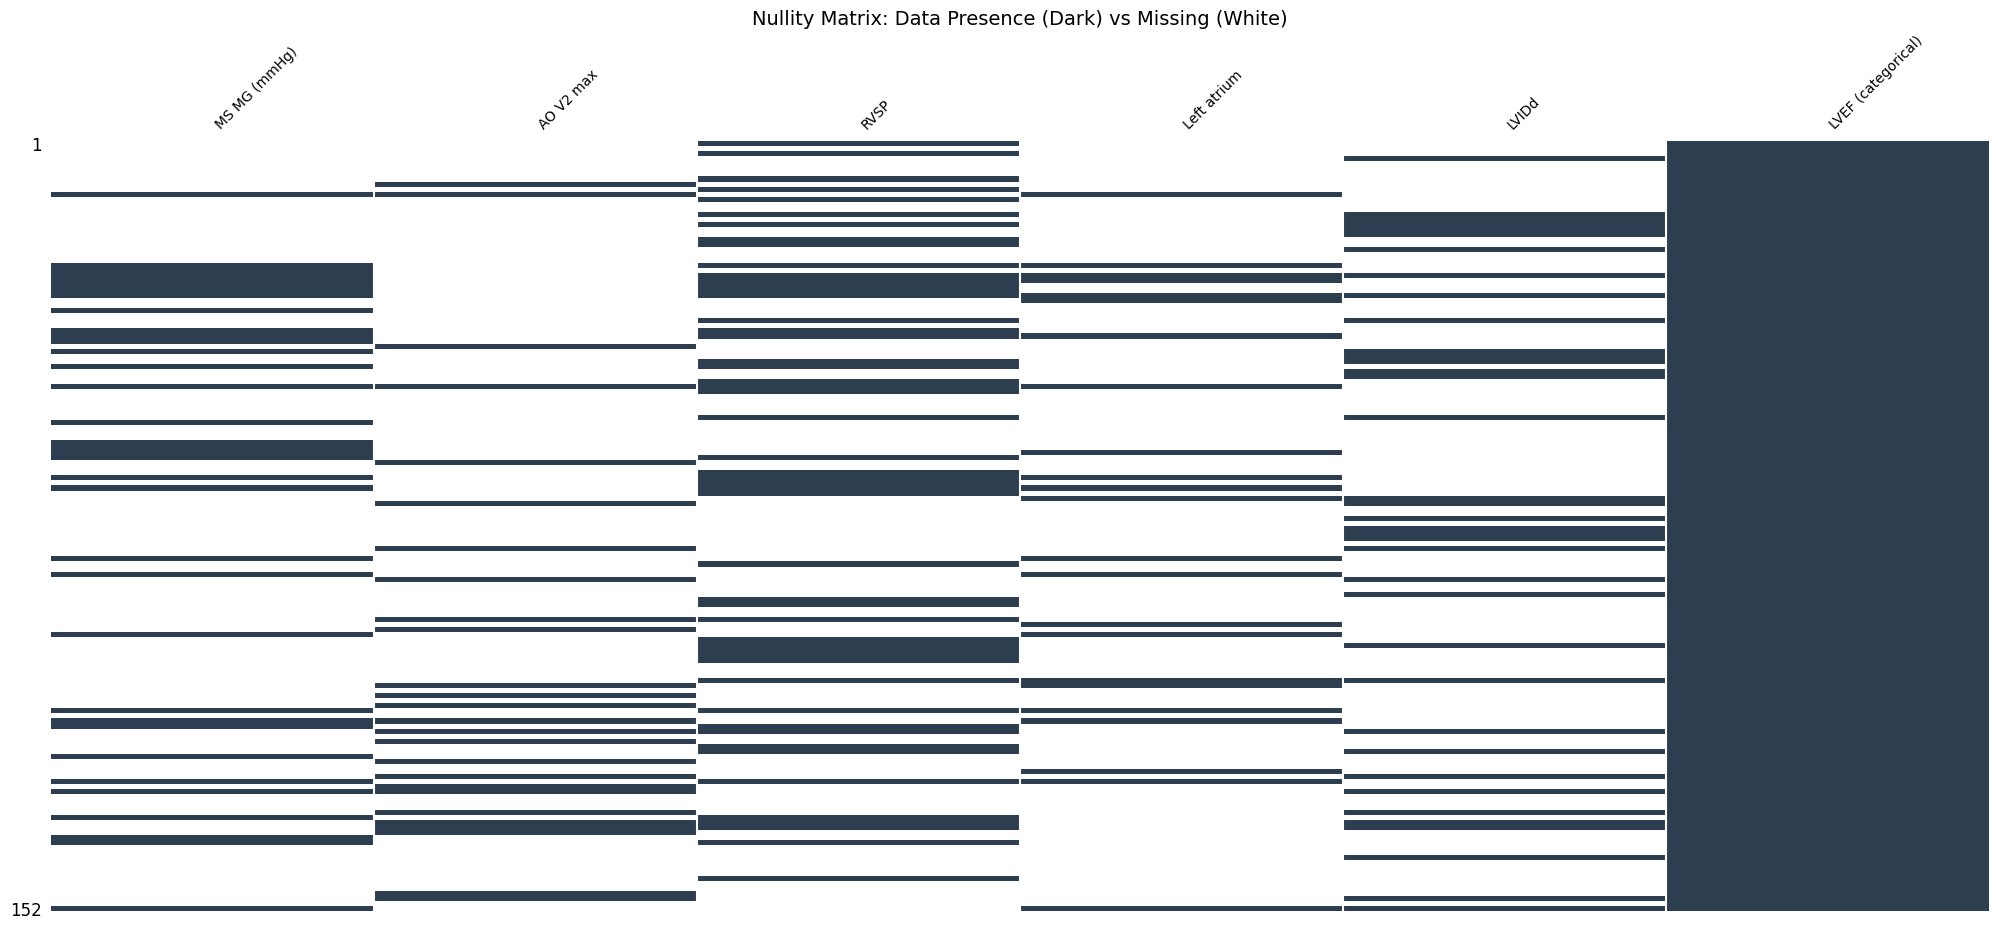

Note: Correlation of Missingness (1.0 = Always missing together):


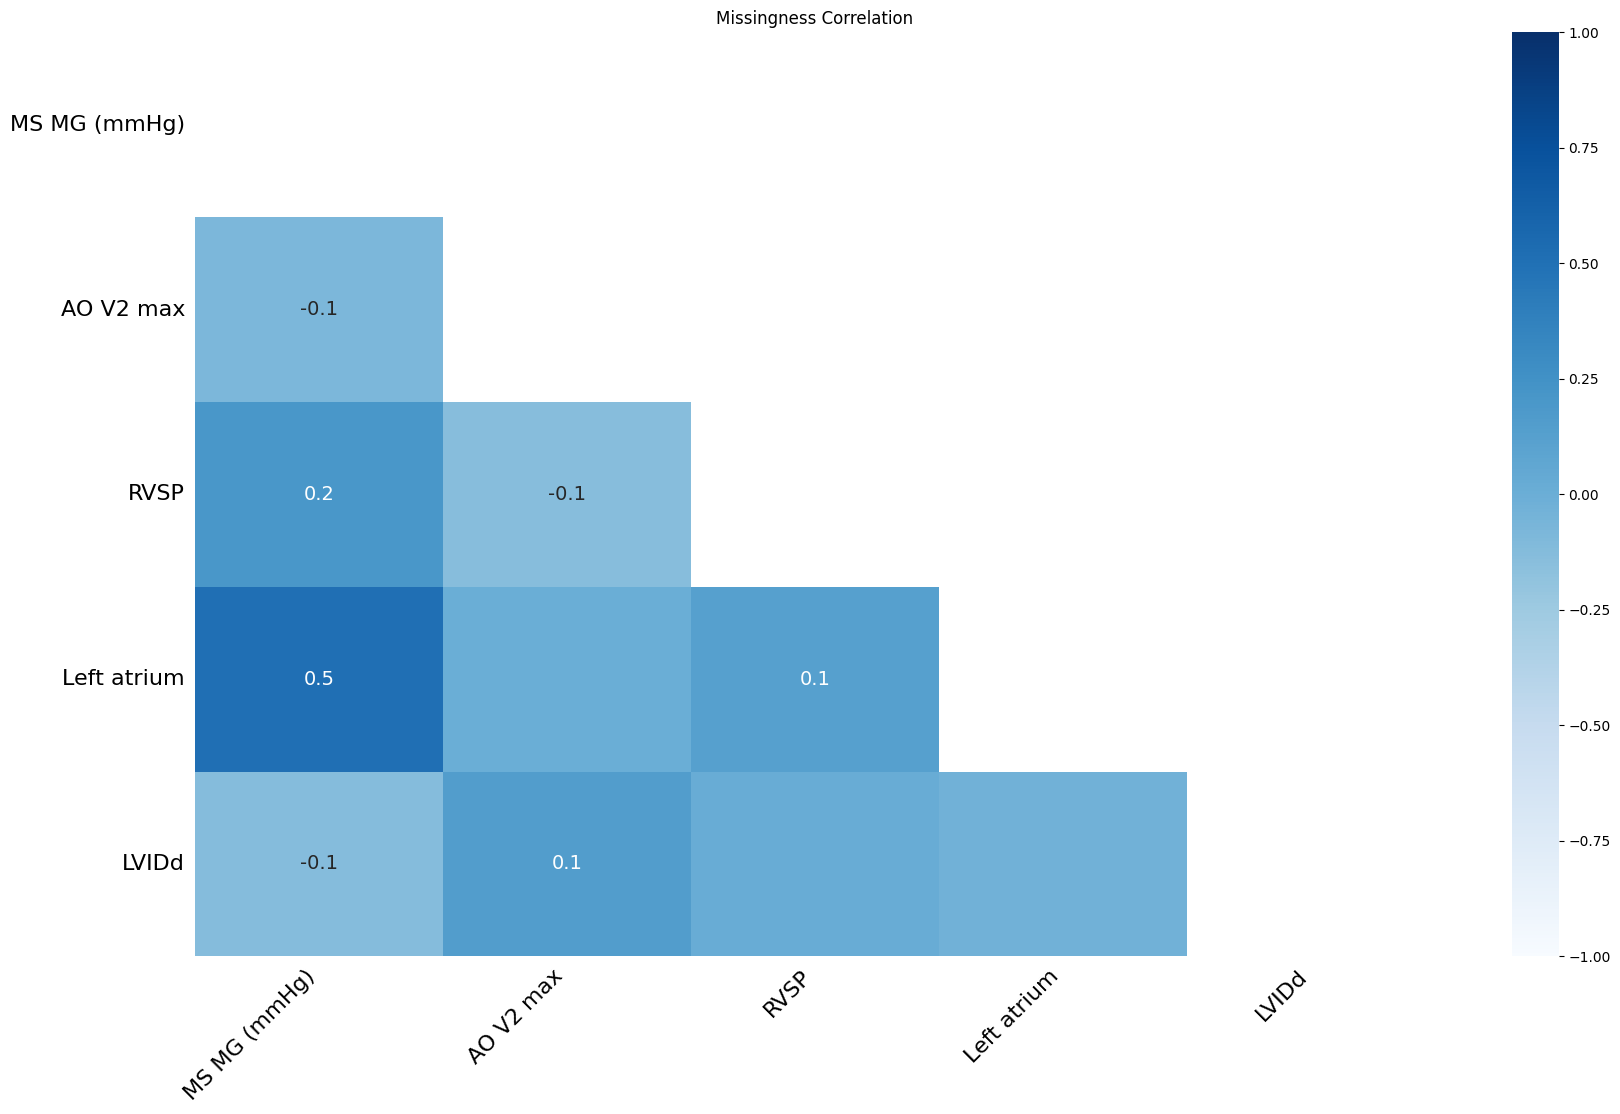

In [8]:
# 1.2. Prints missingness visuals
# We run echo_missingness first to feed its data to the patient_nullity method
missingness_matrix = auditor.echo_missingness() 

viz.patient_nullity()


Echocardiogram Triage Matrix notes:
----------------------------------------
A 'Hot' cell (High %) indicates a parameter the cardiologist deemed mandatory for triage.


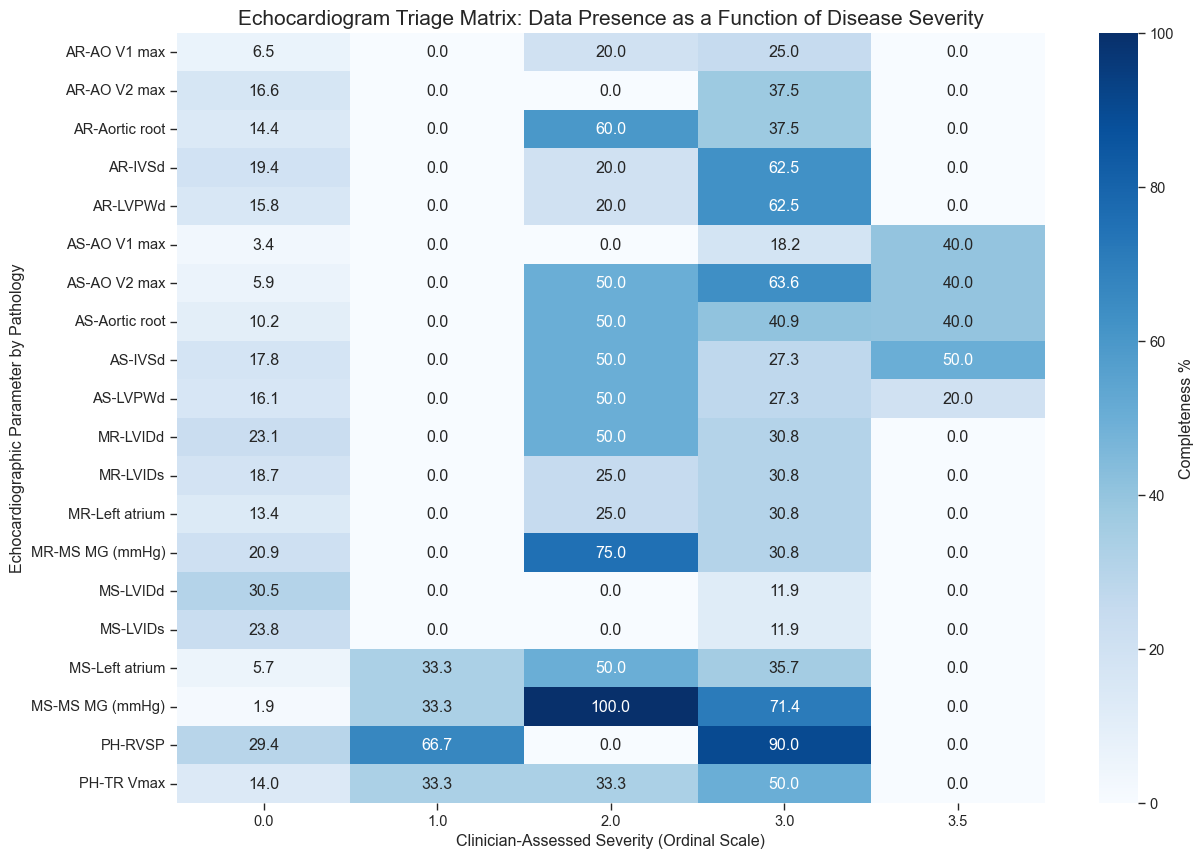

In [9]:
# 1.3. Generates triage matrix
viz.echo_matrix(missingness_matrix)

In [10]:
# PHASE 2: Clinical Baseline & Prevalence
# ==========================================
print(f"PHASE 2: Clinical baseline & prevalence\n{'='*40}")
extractor.baseline()
extractor.disease_profiler()

print(f"\nDisease prevalence: (n={len(df)})\n" + '-'*40)
prevalence = extractor.diagnoses_prevalence()
display(prevalence.head(10))

print("\nDisease complexity\n" + '-'*40)
for key, value in extractor.complexity_stats.items():
    print(f"{key}:  {value}")

PHASE 2: Clinical baseline & prevalence
Baseline characteristics
----------------------------------------


,Value,Completeness,Type
Characteristic,,,
ID,Mode: 1 (0.7%),100.0%,Categorical
Age,47.1 ± 15.7,100.0%,Continuous
Gender,Mode: Female (64.5%),100.0%,Categorical
Weight,71.6 ± 16.2,98.0%,Continuous
OSat,94.9 ± 9.6,99.3%,Continuous
SBP R,124.6 ± 18.7,100.0%,Continuous
DBP R,76.7 ± 12.5,100.0%,Continuous
Heart rate,76.6 ± 14.1,100.0%,Continuous



Disease prevalence: (n=152)
----------------------------------------


,Patient Count,Prevalence (%)
Diagnosis,,
Mitral stenosis,49,32.2
Aortic stenosis,34,22.4
Secundum atrial septal defect,22,14.5
Mitral regurgitation,19,12.5
Pulmonary hypertension,15,9.9
Aortic regurgitation,15,9.9
Surgical aortic valve replacement,14,9.2
Bicuspid aortic valve,12,7.9
Mitral valve percutaneous valvuloplasty,11,7.2



Disease complexity
----------------------------------------
Total Patients:  152
Mixed Mitral:  7
Mixed Aortic:  1
Multi-Valvular:  8
Significant PH (>=2.0):  13
AFib Present:  7



Complexity frequency and stratification
----------------------------------------


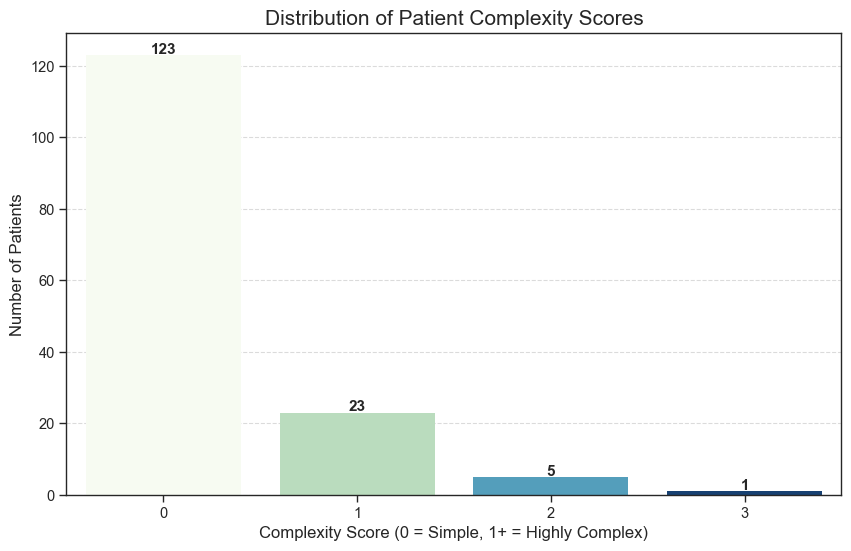

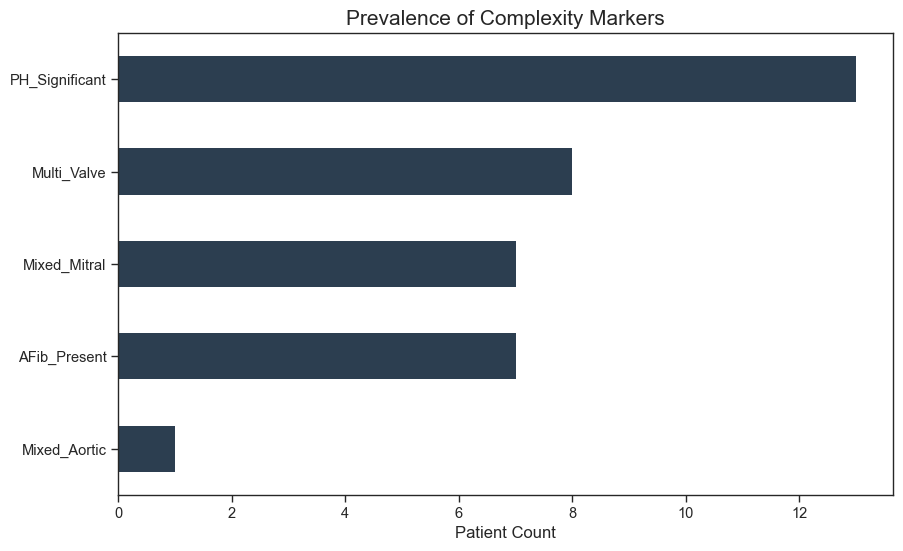

In [11]:
# 2.1. Complexity Analysis
viz = Visualizer(df, config)
stats.df = df

print("\nComplexity frequency and stratification\n" + '-'*40)
viz.complexity_frequency()
viz.complexity_markers()

Echo parameters heatmap interaction
----------------------------------------


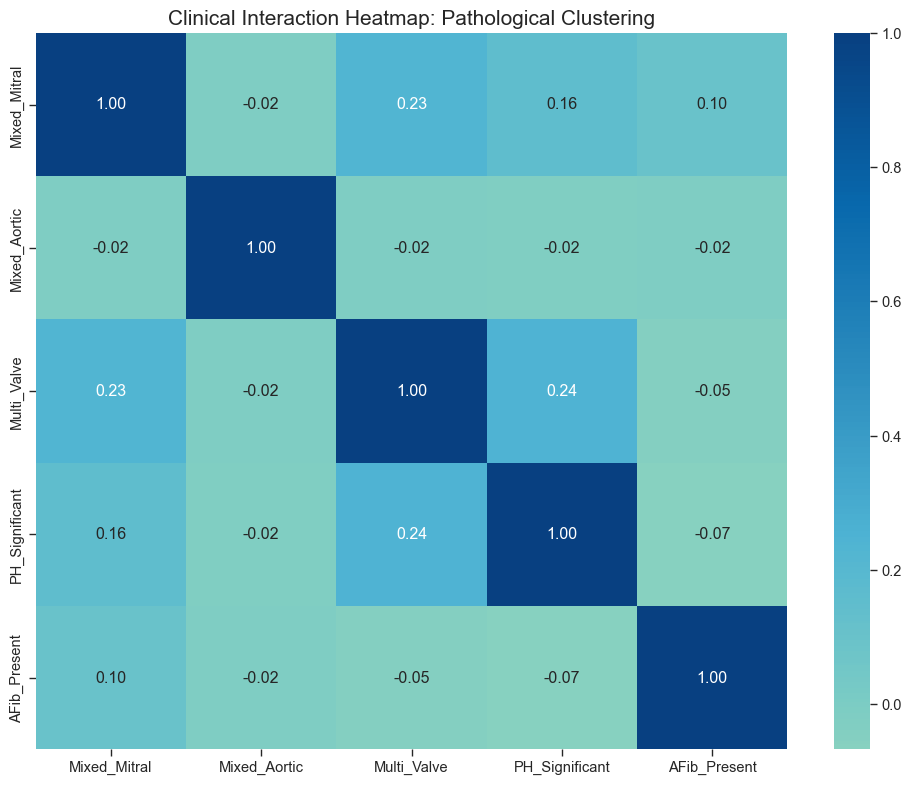

In [12]:
# 2.2. Generates heatmap interaction for our desired echo parameters
print("Echo parameters heatmap interaction\n" + '-'*40)
viz.complexity_heatmap()

In [13]:
# PHASE 3: Statistical Imputation & MBI
# ==========================================
print(f"\nPHASE 3: Statistical Imputation & MBI\n{'='*40}")
stats.apply_imputation()
calculator_execute = calc.medication_index().head(5)


PHASE 3: Statistical Imputation & MBI
Handled MS MG (mmHg) using 'Natural Normal' distribution.
Handled AO V2 max using 'Natural Normal' distribution.
Handled RVSP using 'Natural Normal' distribution.
Handled LVIDd using 'Natural Normal' distribution.


In [14]:
# PHASE 4: Visualizing imputation of Data and MBI validity
# ==========================================
mbi_decomposed = viz.predictor_decomposition()

Global MBI burden, stratified by medication classes
----------------------------------------


Bars represent **aggregate population burden**    
Color indicate **clinical priority** weights


KEY MBI FINDINGS SUMMARY: PHARMACOLOGICAL DRIVERS
Total Cohort Burden Score: 434.9

TOP 3 CLINICAL DRIVERS:
1. Anticoagulants_Antiplatelets | Burden:  90.5 (20.8%)
   - Dominant Medication: Aspirin (47.5% of class)
2. RAAS_Inhibitors           | Burden:  69.2 (15.9%)
   - Dominant Medication: Losartan (55.3% of class)
3. Beta_Blockers             | Burden:  68.3 (15.7%)
   - Dominant Medication: Carvedilol (49.1% of class)




CROSS-STRATA COMPARISON: MBI


,Native Coef,Percutaneous Coef,Surgical Coef
const,2.270 **,1.833,0.436
Sev_MS,0.188,0.741,0.730 *
Sev_MR,0.569 *,-0.167,0.521
Sev_AS,0.082,0.000,0.501 *
Sev_AR,0.121,0.000,0.563
Mixed_Mitral,1.353,-0.056,0.000
Mixed_Aortic,-2.295,0.000,0.000
Multi_Valve,-0.364,0.000,-1.003
Sev_PH,0.604 **,0.000,0.000
AFib_Present,1.881 *,0.000,-0.125


Notes:   ** - p < 0.01 | * - p<0.05

Residuals visualization to compare prediciton errors across intervention groups
----------------------------------------


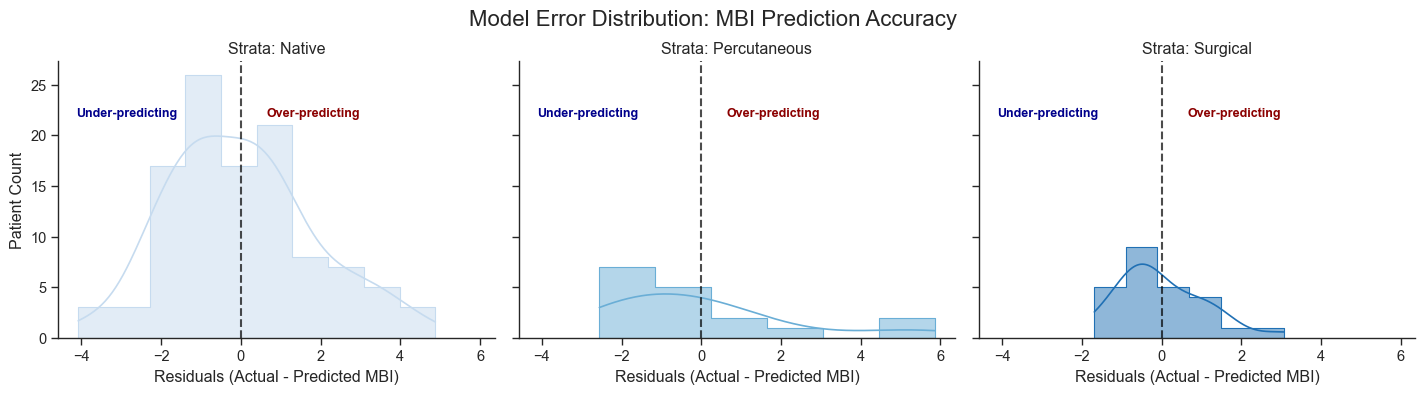

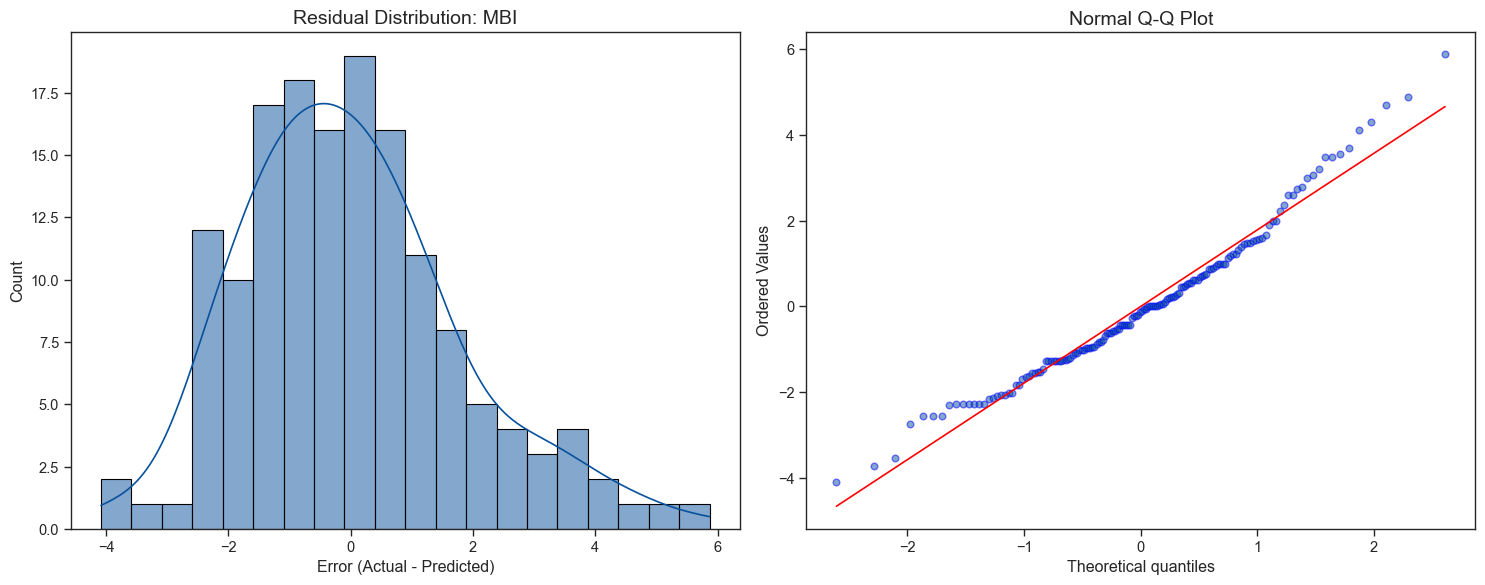

In [15]:
# PHASE 5: Regression for mismatches
# ==========================================
# * Variables to be used for regression
"""
These lists are left empty because we want to run a first, exploratory regression
This will give us an overview into the differences per intervention status
So far, we are going to focus on lesions only, to see how much of this data's MBI
is explained by anatomy of the lesions.
"""
# This are the lists to be passed to the method run_regression
# We are starting with the anatomic variables and then add/modify accordingly
config.regression_echo = []
config.regression_demographics = []
config.regression_lesions = ['Sev_MS','Sev_MR', 'Sev_AS', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'Sev_PH', 'AFib_Present']

# Runs regression across all intervention groups
mbi_mismatch = stats.run_regression(y_var='MBI')

# ! To use residual_distribution method, make sure no strata is selected
print("Residuals visualization to compare prediciton errors across intervention groups\n" + '-'*40)
viz.residual_distribution(mbi_mismatch, y_var='MBI')
viz.diagnostic_plots(mbi_mismatch, y_var='MBI')
# viz.residual_vs_fitted(mbi_mismatch, y_var='MBI')

In [16]:
# PHASE 6: Executive Summary (Final Clinical Insights)
# ==========================================================
print(f"\nPHASE 6: EXECUTIVE SUMMARY & TRIAGE LOGIC (BRIGADE PROTOCOL)\n{'='*70}")

# 1. Final Model Benchmarks
# ----------------------------------------------------------
# The MBI > 4.0 cutoff is based on the 2.27 Native Constant + Mixed Mitral Coef (2.22)
total = len(df)
native_cohort = df[df['Approach'] == 'Native']
avg_mbi_native = native_cohort['MBI'].mean()
high_mbi_n = (df['MBI'] >= 4.0).sum()

# 2. Logic for U-Shaped Triage Filtering (Updated Findings)
# ----------------------------------------------------------

# ZONE 1: THE "UNDER-TREATED" SILENT NATIVE (Priority 1)
# These are the Mismatch cases (Low meds but physiological strain)
# Identifying patients with MBI below the Native Constant (2.27) but significant RVSP or MS MG
silent_native_mask = (
    (df['Approach'] == 'Native') & 
    (df['MBI'] <= 2.5) & 
    ((df['RVSP_Imputed'] > 50) | (df['MS MG (mmHg)_Imputed'] > 10))
)
silent_n = silent_native_mask.sum()

# ZONE 2: THE "SURGICAL SWEET SPOT" (Priority 2)
# MBI between 4.0 and 5.5. Focusing on the Hyperdynamic Paradox (EF > 70)
# These hearts are compensating but at high risk of dilation burnout.
sweet_spot_mask = (
    (df['Approach'] == 'Native') &
    (df['MBI'] >= 4.0) & (df['MBI'] < 5.5)
)
sweet_spot_n = sweet_spot_mask.sum()

# ZONE 3: THE "MIXED MITRAL" ACCELERATOR
# Regardless of MBI, Mixed Mitral carries a Coef of 2.22 (The strongest predictor)
mixed_mitral_mask = (df['Mixed_Mitral'] == 1) & (df['Approach'] == 'Native')
mixed_n = mixed_mitral_mask.sum()

# ZONE 4: HIGH-RISK / PALLIATIVE (The "Chimney" Group)
# Extreme MBI (> 6.0) and extreme RVSP residuals (> 80)
palliative_mask = (df['MBI'] >= 5.5) | (df['RVSP_Imputed'] > 60)
palliative_n = palliative_mask.sum()

# 3. Output Display
# ----------------------------------------------------------
print(f"COHORT METRICS:")
print(f"  - Total Patients Analyzed:    {total}")
print(f"  - Cohort Constant Baseline:   2.27 (Weighted MBI)")
print(f"  - Avg Native MBI:             {avg_mbi_native:.2f}")
print(f"  - High Complexity (MBI > 4):  {high_mbi_n} cases")

print(f"\nBRIGADE TRIAGE LOGIC (U-SHAPE FILTERING):")
print("-" * 60)
print(f"  [PRIORITY 1] SILENT NATIVES:        {silent_n}")
print(f"               (MBI < 2.5 but RVSP > 50. High risk of sudden decompensation.)")

print(f"  [PRIORITY 2] SURGICAL SWEET SPOT:   {sweet_spot_n}")
print(f"               (MBI 4.0-5.5. Optimal ROI for intervention.)")

print(f"  [CRITICAL]   MIXED MITRAL PHENOTYPE: {mixed_n}")
print(f"               (Strongest Predictor: Coef 2.22. Requires Priority.)")

print(f"  [CAUTION]    HIGH-RISK/PALLIATIVE:   {palliative_n}")
print(f"               (MBI > 5.5 or RVSP > 60. 'Chimney' Outliers - Surgical futility evaluation.)")

print(f"\nTECHNICAL NOTE:")
print(f"MBI Weights Applied: Loop Diuretics/Vasodilators (3.0), RAASi/BB/MRA (2.0), \nMaintenance (1.0). R-Squared of Final Integrated Model: 0.329")


PHASE 6: EXECUTIVE SUMMARY & TRIAGE LOGIC (BRIGADE PROTOCOL)
COHORT METRICS:
  - Total Patients Analyzed:    152
  - Cohort Constant Baseline:   2.27 (Weighted MBI)
  - Avg Native MBI:             3.03
  - High Complexity (MBI > 4):  39 cases

BRIGADE TRIAGE LOGIC (U-SHAPE FILTERING):
------------------------------------------------------------
  [PRIORITY 1] SILENT NATIVES:        8
               (MBI < 2.5 but RVSP > 50. High risk of sudden decompensation.)
  [PRIORITY 2] SURGICAL SWEET SPOT:   19
               (MBI 4.0-5.5. Optimal ROI for intervention.)
  [CRITICAL]   MIXED MITRAL PHENOTYPE: 5
               (Strongest Predictor: Coef 2.22. Requires Priority.)
  [CAUTION]    HIGH-RISK/PALLIATIVE:   26
               (MBI > 5.5 or RVSP > 60. 'Chimney' Outliers - Surgical futility evaluation.)

TECHNICAL NOTE:
MBI Weights Applied: Loop Diuretics/Vasodilators (3.0), RAASi/BB/MRA (2.0), 
Maintenance (1.0). R-Squared of Final Integrated Model: 0.329


In [17]:
# 6.1. Pharmacological drivers summary
print(f"\nPHARMACOLOGICAL DRIVERS SUMMARY:")
print("-" * 40)
# Showing top medication drivers as previously calculated
for category, burden in config.class_weights.items():
    # Find the dominant drug in this category from your df_comp
    top_drug = mbi_decomposed[mbi_decomposed['Medication_Class'] == category].nlargest(1, 'Burden_Score')
    drug_name = top_drug['Specific_Drug'].values[0]
    drug_pct = top_drug['Percentage_of_Class'].values[0]
    print(f"  - {category:<25} | Burden: {burden:>5.1f} (Lead: {drug_name} {drug_pct:.1f}%)")

print("\nDISEASE PREVALENCE:")
display(prevalence.head(10))


PHARMACOLOGICAL DRIVERS SUMMARY:
----------------------------------------
  - Diuretics_Loop            | Burden:   3.0 (Lead: Furosemide 100.0%)
  - Pulmonary_Vasodilators    | Burden:   3.0 (Lead: Sildenafil 77.7%)
  - RAAS_Inhibitors           | Burden:   2.0 (Lead: Losartan 55.3%)
  - SGLT2_Inhibitors          | Burden:   2.0 (Lead: Dapaglifozin 73.5%)
  - Diuretics_Other           | Burden:   2.0 (Lead: Spironolactone 95.3%)
  - Beta_Blockers             | Burden:   2.0 (Lead: Carvedilol 49.1%)
  - Rate_Rhythm_Control       | Burden:   1.0 (Lead: Digoxin 95.7%)
  - Anticoagulants_Antiplatelets | Burden:   1.0 (Lead: Aspirin 47.5%)
  - Calcium_Channel_Blockers  | Burden:   1.0 (Lead: Amlodipine 84.4%)
  - Anti_Ischemic_Other       | Burden:   1.0 (Lead: Trimetazidine 67.2%)
  - Lipid_Lowering            | Burden:   0.5 (Lead: Simvastatin 46.2%)
  - Metabolic_Endocrine       | Burden:   0.5 (Lead: Levothyroxine 54.0%)

DISEASE PREVALENCE:


,Patient Count,Prevalence (%)
Diagnosis,,
Mitral stenosis,49,32.2
Aortic stenosis,34,22.4
Secundum atrial septal defect,22,14.5
Mitral regurgitation,19,12.5
Pulmonary hypertension,15,9.9
Aortic regurgitation,15,9.9
Surgical aortic valve replacement,14,9.2
Bicuspid aortic valve,12,7.9
Mitral valve percutaneous valvuloplasty,11,7.2


In [18]:
# 6.2. We define Zones with Counts
bins = [0, 4.0, 5.5, np.inf]
labels = ['Zone 1', 'Zone 2', 'Zone 3']
df['MBI_Zone'] = pd.cut(df['MBI'], bins=bins, labels=labels, right=False)
mbi_mismatch['MBI_Zone'] = pd.cut(mbi_mismatch['MBI'], bins=bins, labels=labels, right=False)

# We calculate counts for header labels
counts = df['MBI_Zone'].value_counts()
header_labels = {zone: f"{zone} (n={counts[zone]})" for zone in labels}

In [19]:
# We construct table 1
rows = [
    ('Age (years)', 'Age', 'mean'),
    ('Female (%)', 'Gender', 'pct'),
    ('Heart Rate (bpm)', 'Heart rate', 'mean'),
    ('Systolic BP (mmHg)', 'SBP R', 'mean'),
    ('Diastolic BP (mmHg)', 'DBP R', 'mean'),
    ('RVSP (mmHg)', 'RVSP_Imputed', 'mean'),
    ('LVEF (%)', 'LVEF_Score', 'mean'),
]

table_one = pd.DataFrame()

# Column A: All Patients (N=152)
col_all = []
for label, col, is_pct in rows:
    col_all.append(stats.format_stat(df, col, is_pct))
table_one['All Patients (N=152)'] = col_all

# Columns B-E: Triage Zones
for zone in labels:
    zone_df = df[df['MBI_Zone'] == zone]
    col_zone = []
    for label, col, is_pct in rows:
        col_zone.append(stats.format_stat(zone_df, col, is_pct))
    table_one[header_labels[zone]] = col_zone

table_one.index = [r[0] for r in rows]

In [20]:
# 6.4. We construct table 2

rows = [
    ('Age (years)', 'Age', 'mean'),
    ('Female (%)', 'Gender', 'pct'),
    ('Heart Rate (bpm)', 'Heart rate', 'mean'),
    ('Systolic BP (mmHg)', 'SBP R', 'mean'),
    ('Diastolic BP (mmHg)', 'DBP R', 'mean'),
    ('RVSP (mmHg)', 'RVSP_Imputed', 'mean'),
    ('LVEF (%)', 'LVEF_Score', 'mean'),
    ('MBI', 'MBI', 'mean')
]

table_two = pd.DataFrame()

# Column A: All Patients (N=152)
col_all = []
for label, col, is_pct in rows:
    col_all.append(stats.format_stat(df, col, is_pct))
table_two['All Patients (N=152)'] = col_all

for approach in ['Native', 'Percutaneous', 'Surgical']:
    app_df = df[df['Approach'] == approach]
    table_two[f'{approach} (n={len(app_df)})'] = [
        stats.format_stat(app_df, col, is_pct) for _, col, is_pct in rows
        ]
    
table_two.index = [r[0] for r in rows]

---

## **3. Introduction and Objectives**

### **3.1. Scientific Background & Intended Use**  
In high-volume cardiac outreach missions, clinical throughput often outpaces formal data documentation. During the 2025 León, Nicaragua mission, a small team screened over 187 patients in just seven days. In such "clinical sprints," documentation is prioritized for pathological findings, while healthy parameters are frequently left blank—a phenomenon we term the "Silence of the Normal."

This creates a Missing Not At Random (MNAR) bias that complicates traditional statistical analysis. The Medication Burden Index (MBI) was developed post-hoc as a feature-engineered proxy to quantify clinical effort by aggregating pharmacological intensity. Its intended role is to serve as a high-throughput triage tool, identifying the "Intervention Sweet Spot"—patients whose high pharmacological demand signals significant anatomical complexity before they reach end-stage hemodynamic exhaustion.

### **3.2. Study objectives**  

**Primary Objective:** To evaluate the diagnostic accuracy of the Medication Burden Index (MBI)—a pharmacological intensity score—in identifying patients with critical hemodynamic decompensation (RVSP > 60 mmHg).

**Secondary Objectives:**  

1. **Baseline Characterization:** To determine the "Native Constant" of the mission cohort, establishing the average pharmacological footprint of patients in this resource-limited setting.  

2. **Complexity Mapping:** To quantify the additive impact of "Phenotypic Complexity" (mixed and multi-valvular disease) on medication intensity.

3. **Triage Framework Development:** To derive evidence-based MBI thresholds that segment the intervention queue into actionable, risk-stratified triage zones.

## **4. Methods**  

### **4.1. Study Design and Setting**  
This is a retrospective diagnostic accuracy study. Participants represent a consecutive series of all patients ($N=187$) presenting to the Phase 1 clinic in León, Nicaragua, in February 2025.

### **4.2. Participants**  
This project analyzes real-world clinical data from a high-volume medical mission in León, Nicaragua. The brigade operates via a structured, three-phase clinical workflow designed to bridge the gap between primary screening and advanced cardiac intervention:

* **Phase 1 — General Cardiology Clinic:** High-throughput diagnostic screening, echocardiographic evaluation, and procedure prioritization.

* **Phase 2 — Electrophysiology:** Arrhythmia management, including cardiac ablations and permanent pacemaker/ICD implantation.

* **Phase 3 — Interventional Cardiology:** Percutaneous structural heart procedures and collaborative case reviews.  

Due to the rapid pace of the mission, data entry followed a "documentation by exception" rule. Patients were excluded ($N=35$) if they were under 15 years old or exhibited entirely normal findings, focusing the analysis on the $N=152$ structural heart disease cohort.

### **4.3. Test methods**  

**4.3.1. The Index Test: Medication Burden Index (MBI)**  
The MBI is a weighted summation of pharmacological intensity. Medications are weighted by clinical priority and normalized by the ratio of actual dose to maximum daily dose (TDD).

$$MBI = \sum_{i=1}^{n} \left( \text{Weight}_{\text{class}_i} \times \frac{\text{TDD}_i}{\text{Dose}_{\text{max}_i}} \right)$$

* **Weight:** Assigned based on the drug's therapeutic impact on valvular hemodynamics (e.g., Loop Diuretics have a higher weight than Lipid Lowering agents).

* **Dose Ratio:** Normalizes intra-group intensity. This ensures that "burden" reflects clinical effort (percent of maximum titration) rather than raw milligram mass.

*Clinical Validation: The Normalization of Calcium Channel Blockers (CCBs)*

To understand why the Total Daily Dose (TDD) and Dose Ratio are necessary, consider two patients on different CCBs from our cohort:

| Patient | Medication | Raw dosage | Frequency | Total Daily Dose (TDD) | Max Daily dose | Dose ratio |
| :- | :- | -: | :- | -: | -: | -: |
| A | **Nifedipine** | 20 mg | BID | 40 mg | 120 mg | 0.33 |
| B | **Amlodipine** | 10 mg | QD | 10 mg | 10 mg | 1.00 |  

* **Total Daily Dose (TDD):** Raw milligrams are misleading. The extraction engine must calculate the Total Daily Dose (TDD) by multiplying dosage by frequency (e.g., $20\text{ mg } BID = 40\text{ mg}$).

* **Normalization:** Without the Dose Ratio, Patient A would appear to have four times the "burden" of Patient B ($40\text{ mg}$ vs $10\text{ mg}$). In reality, Patient B is at 100% therapeutic ceiling, reflecting a more aggressive clinical strategy. The MBI correctly identifies Patient B as the higher-intensity case.

**4.3.2. The Reference Standard: Echocardiography**  
Transthoracic Echocardiography (TTE) was performed by board-certified cardiologists. RVSP was selected as the primary anchor for validation because it represents the final common pathway of valvular decompensation and is a primary determinant of intervention eligibility in resource-limited settings.

---

### **4.4. Analysis**  

**4.4.1. Handling Missing Data: The "Silence of the Normal"**  
Missing values are treated as Missing Not At Random (MNAR) due to the high-throughput nature of the mission where normal valves were intentionally left unrecorded. We utilize Natural Normal Imputation to reconstruct the healthy baseline:  
$$X_{imp} \sim \mathcal{N}(\mu_{healthy}, \sigma^{2}_{phys})$$

**4.4.2. Cut-off Determination**  
The optimal diagnostic threshold for the MBI was determined post-hoc using the Youden’s J-statistic ($J = \text{Sensitivity} + \text{Specificity} - 1$) relative to the RVSP 60 mmHg threshold.

**4.4.3. Quantifying Discordance**  
To establish the clinical utility of the MBI, we first performed a Receiver Operating Characteristic (ROC) analysis. We defined the clinical "True Positive" as an RVSP > 60 mmHg, in order for determining hemodynamic significance in valvular disease.

We utilized Residual Analysis as the primary measure of accuracy. A linear regression model established the relationship between hemodynamic severity (Reference Standard) and MBI (Index Test).

* **Negative Residuals:** Indicate an "Under-medicated Gap" (Anatomy > Pharmacology).

* **Positive Residuals:** Indicate "Phenotypic Complexity" (Pharmacology > Anatomy).

**4.4.4. Triage zones and Residual analysis**
Based on the optimal Youden’s J-statistic from the ROC, we established Triage Zones:

* **Zone 1:** The "Stable/Monitor" tier

* **Zone 2:** The "Intervention Sweet Spot"

* **Zone 3:** The "High-Risk / Palliative" Tier

---

## **5. Results**  

**5.1. Participant flow and Baseline characteristics**    
Following the exclusion of pediatric cases (<15 yrs) and non-structural findings, the final study cohort consisted of $N=152$ patients. The population was predominantly female (64.5%), with a high prevalence of percutaneous candidates (88.2% female). Hemodynamic profiles remained stable across the groups (Mean BP 124/76 mmHg), suggesting that medication burden variance was driven by cardiac complexity rather than systemic hypertension.

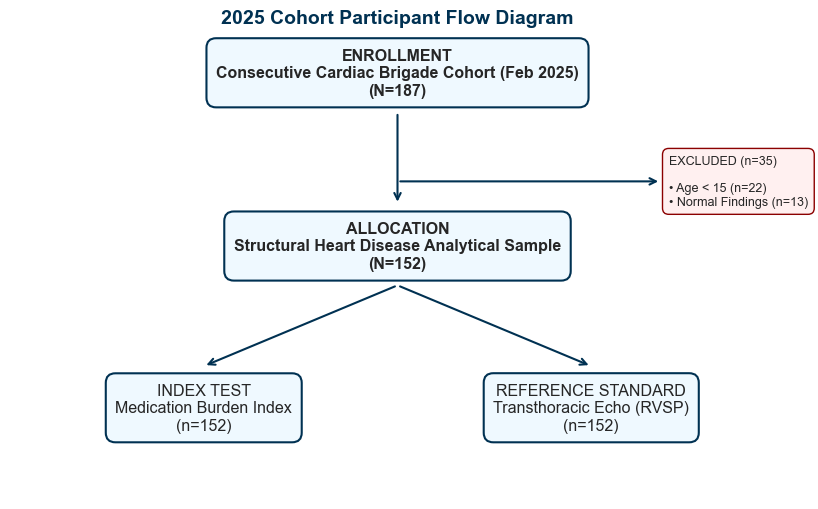

In [21]:
# Participant flowchart
viz.plot_flowchart()

In [22]:
# Table 1: Baseline Characteristics Stratified by MBI Triage Zone
print("Table 1: Baseline Characteristics Stratified by MBI Triage Zone")
display(table_one)

Table 1: Baseline Characteristics Stratified by MBI Triage Zone


,All Patients (N=152),Zone 1 (n=113),Zone 2 (n=22),Zone 3 (n=17)
Age (years),47.1 ± 15.7,45.3 ± 16.4,54.6 ± 10.1,49.8 ± 13.4
Female (%),64.5%,58.4%,77.3%,88.2%
Heart Rate (bpm),76.6 ± 14.1,76.2 ± 14.2,79.5 ± 14.2,75.8 ± 14.1
Systolic BP (mmHg),124.6 ± 18.7,127.4 ± 18.7,113.6 ± 17.0,120.9 ± 15.2
Diastolic BP (mmHg),76.7 ± 12.5,77.7 ± 12.9,72.9 ± 10.3,75.2 ± 11.6
RVSP (mmHg),34.0 ± 20.0,31.5 ± 16.9,35.6 ± 16.2,48.6 ± 33.9
LVEF (%),56.6 ± 10.1,57.6 ± 9.1,52.7 ± 13.7,55.0 ± 10.3


In [23]:
# Table 2: Baseline Characteristics stratified by valve status
print('Table 2: Baseline Characteristics stratified by valve status')
display(table_two)

Table 2: Baseline Characteristics stratified by valve status


,All Patients (N=152),Native (n=110),Percutaneous (n=17),Surgical (n=25)
Age (years),47.1 ± 15.7,47.7 ± 16.0,42.9 ± 14.4,47.4 ± 14.9
Female (%),64.5%,61.8%,88.2%,60.0%
Heart Rate (bpm),76.6 ± 14.1,76.3 ± 14.5,71.2 ± 13.2,81.5 ± 11.8
Systolic BP (mmHg),124.6 ± 18.7,124.8 ± 19.4,123.8 ± 18.2,124.7 ± 16.3
Diastolic BP (mmHg),76.7 ± 12.5,76.6 ± 13.6,75.7 ± 9.7,77.7 ± 8.2
RVSP (mmHg),34.0 ± 20.0,36.3 ± 22.4,31.9 ± 13.1,25.1 ± 3.5
LVEF (%),56.6 ± 10.1,55.5 ± 11.6,58.2 ± 3.9,60.0 ± 0.0
MBI,2.9 ± 2.1,3.0 ± 2.2,3.2 ± 2.6,1.9 ± 1.4


**5.2. Impact of the "Natural Normal" imputation**  
The raw dataset exhibited a significant "Silence of the Normal" bias, where healthy cardiac parameters were frequently omitted in the high-volume mission setting. Gaussian noise injection ($RVSP \sim \mathcal{N}(25, 4)$) successfully restored the physiological baseline.Finding: KDE plots confirm that imputation shifted the cohort mean toward a realistic population distribution, preventing an artificial inflation of the MBI's sensitivity by including a statistically valid "low-risk" group.

Sensitivity analysis for the Stochastic Imputation
----------------------------------------


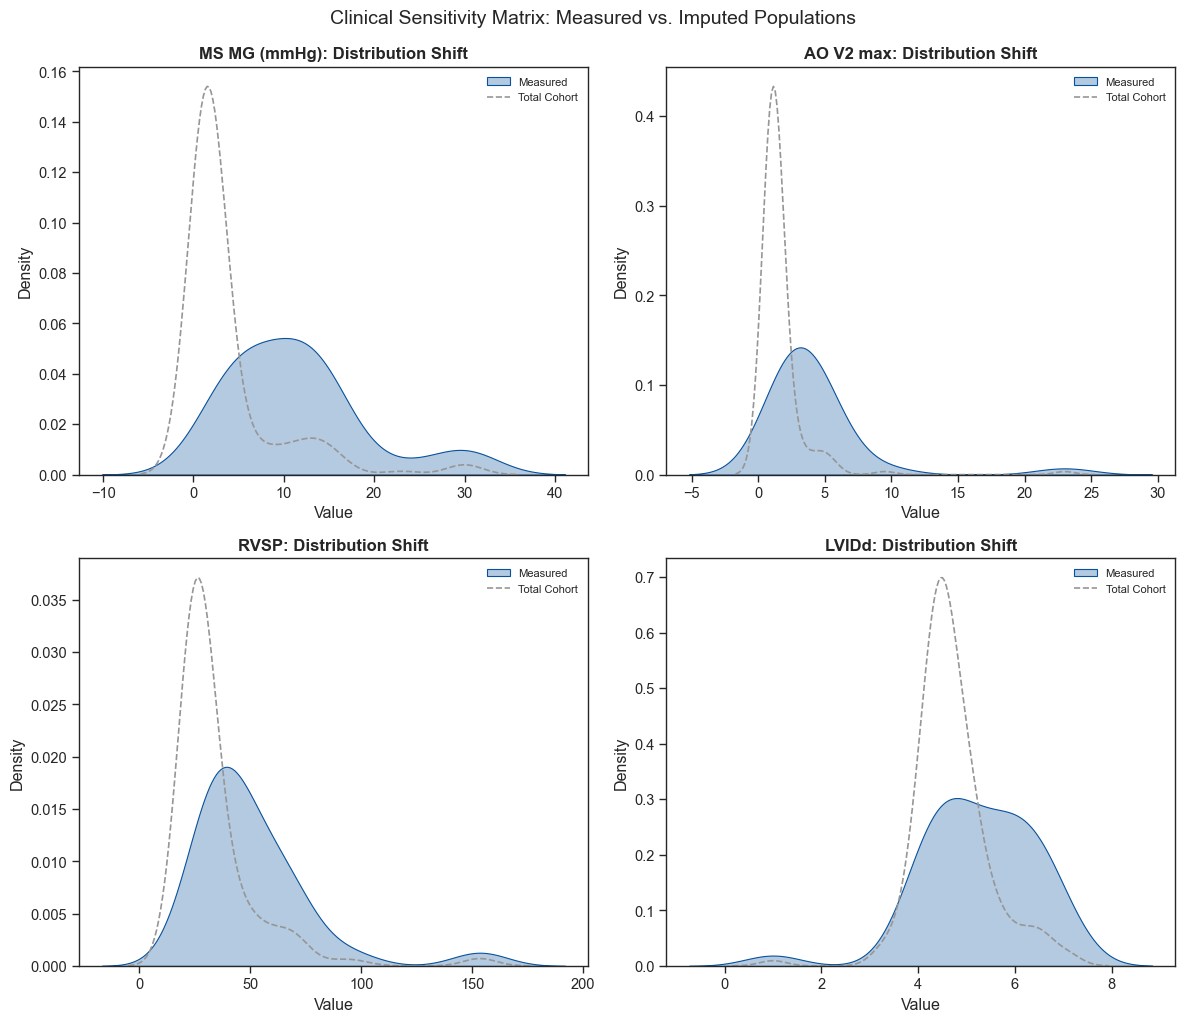

,Measured Mean,Cohort Mean,Delta (Shift),Triage Bias,Sample Size (n)
Clinical Parameter,,,,,
MS MG (mmHg),11.4,3.8,-7.6,Significant Shift,35
AO V2 max,4.3,1.7,-2.6,Significant Shift,26
RVSP,51.0,34.0,-17.0,Significant Shift,51
LVIDd,5.2,4.7,-0.5,Significant Shift,37


In [24]:
# Sensitivity analysis for the "Natural Normal" imputation
print("Sensitivity analysis for the Stochastic Imputation\n" + '-'*40)
viz.sensitivity_grid()
sensitivity_table = stats.sensitivity_report()
display(sensitivity_table)

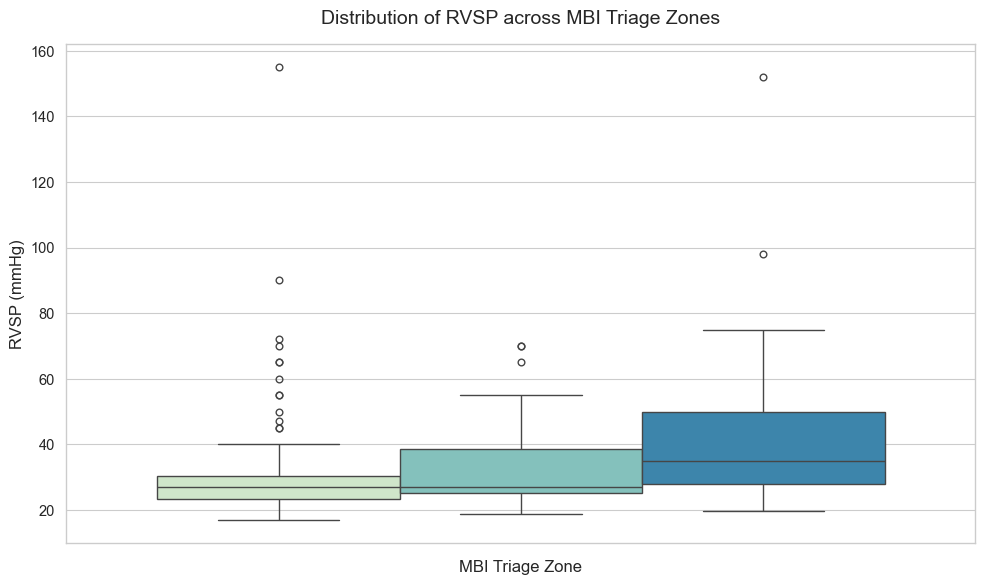

In [25]:
# Boxplot: Distribution of RVSP across MBI triage zones
# Base styling
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We create the Boxplot
ax = sns.boxplot(hue='MBI_Zone', y='RVSP_Imputed', data=df, 
                 palette="GnBu", showfliers=True, legend=False)

# Titles and labels
plt.title('Distribution of RVSP across MBI Triage Zones', fontsize=14, pad=15)
plt.xlabel('MBI Triage Zone', fontsize=12)
plt.ylabel('RVSP (mmHg)', fontsize=12)

plt.tight_layout()
plt.show()

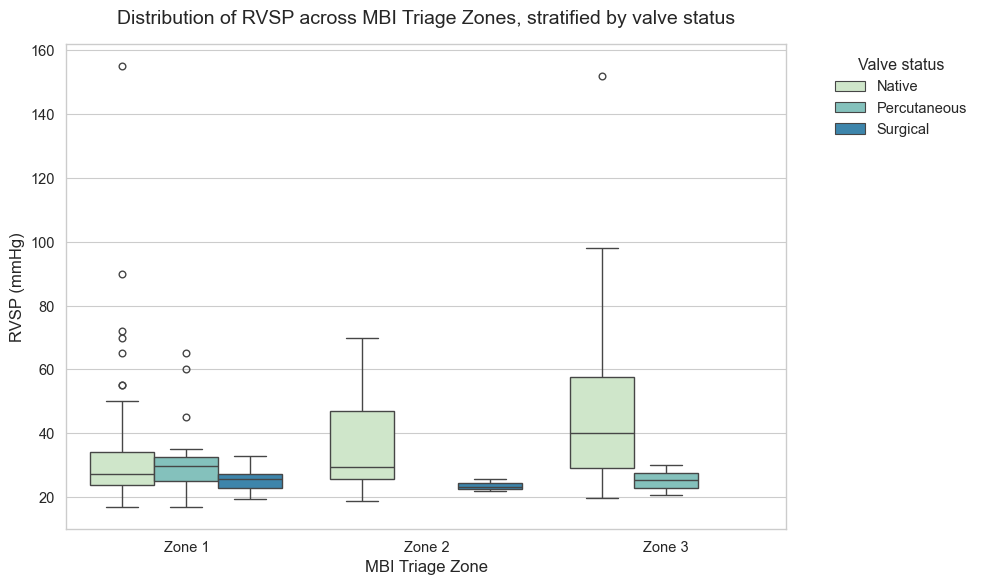

In [26]:
# Boxplot: Distribution of RVSP across MBI triage zones, stratified by valve status
# Base styling
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We create the Boxplot
ax = sns.boxplot(x='MBI_Zone', y='RVSP_Imputed', hue='Approach', data=df, 
                 palette="GnBu", showfliers=True)

# Titles and labels
plt.title('Distribution of RVSP across MBI Triage Zones, stratified by valve status', fontsize=14, pad=15)
plt.xlabel('MBI Triage Zone', fontsize=12)
plt.ylabel('RVSP (mmHg)', fontsize=12)

plt.legend(title='Valve status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

ROC visualization for MBI
----------------------------------------


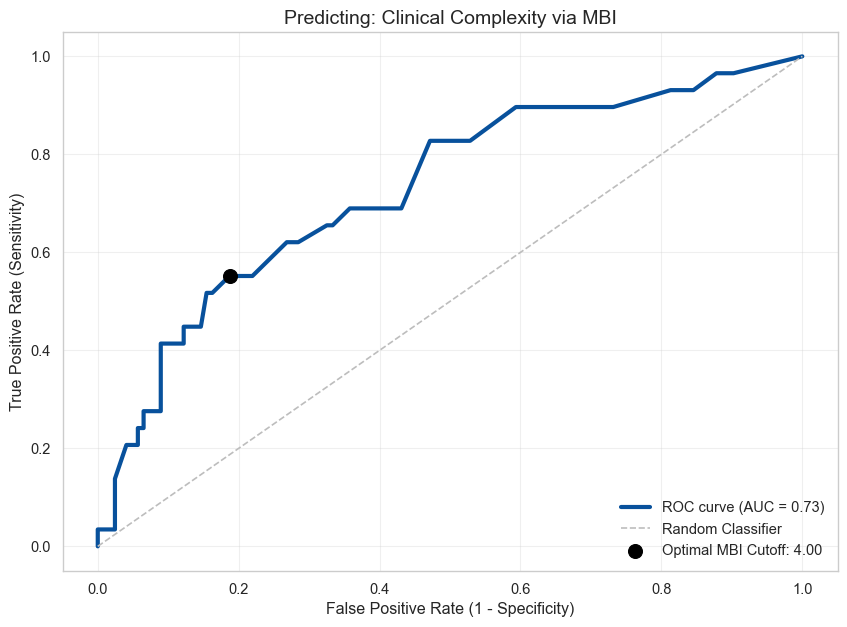

Analysis Complete: A value of MBI above 4.00 is the best predictor of patient complexity.

MBI Threshold Validation (> 4.0)
----------------------------------------
F1-Score:  0.421
Precision: 0.800 (Reliability: When MBI is high, is the patient actually sick?)
Recall:    0.286 (Sensitivity: Does MBI catch all the sick patients?)

Confusion matrix visualization
----------------------------------------


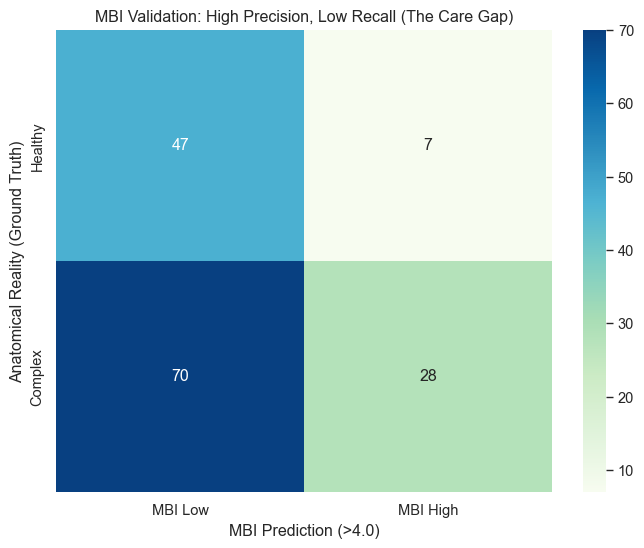

In [27]:
# ROC analysis: Validation of the MBI threshold for anatomical complexity
stats.roc(predictor_col='MBI')

# 2.0 for a moderate cutoff
anatomical_threshold = 2.0 
df['Is_Complex_Anatomic'] = (df[config.lesions_anatomic].max(axis=1) >= anatomical_threshold).astype(int)

# Apply the MBI Cutoff
mbi_cutoff = 4.0
df['MBI_Predicted_High'] = (df['MBI'] > mbi_cutoff).astype(int)
matrix = stats.validate_predictor(mbi_cutoff)
viz.validate_vis(matrix, 
                 'MBI Prediction (>4.0)', 'Anatomical Reality (Ground Truth)', 
                 'MBI Validation: High Precision, Low Recall (The Care Gap)'
)

ROC visualization for MBI
----------------------------------------


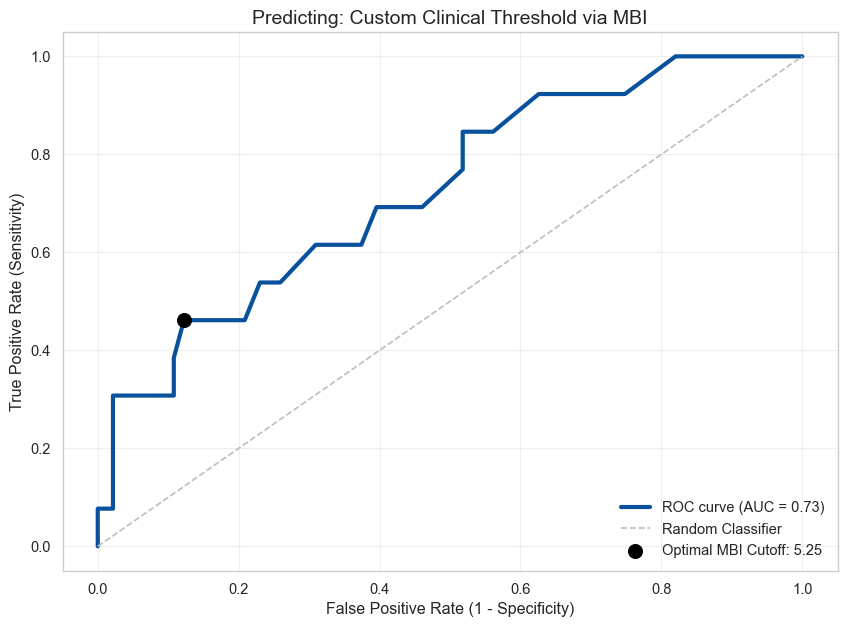

Analysis Complete: A value of MBI above 5.25 is the best predictor of patient complexity.

MBI Threshold Validation (> 5.25)
----------------------------------------
F1-Score:  0.288
Precision: 0.850 (Reliability: When MBI is high, is the patient actually sick?)
Recall:    0.173 (Sensitivity: Does MBI catch all the sick patients?)

Confusion matrix visualization
----------------------------------------


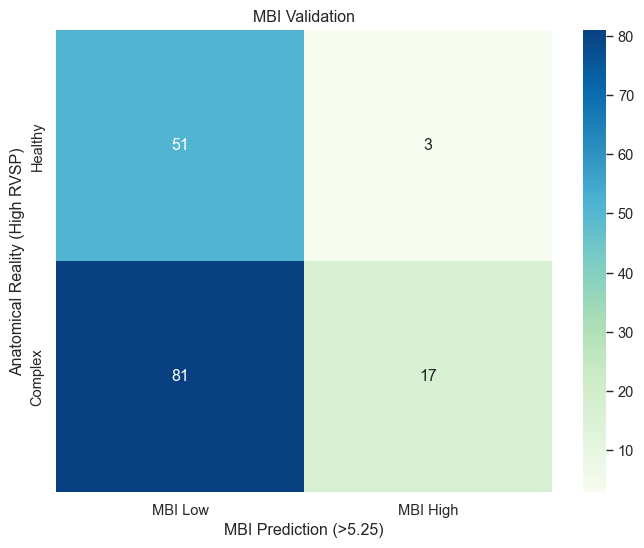

In [28]:
# ROC analysis: Validation of the MBI threshold to predict high RVSP
stats.roc(predictor_col='MBI', target=(df['RVSP_Imputed'] > 60))

# Apply the MBI Cutoff (The Predictor)
mbi_cutoff = 5.25
df['MBI_Predicted_High'] = (df['MBI'] > mbi_cutoff).astype(int)
matrix_rvsp = stats.validate_predictor(mbi_cutoff)
viz.validate_vis(matrix_rvsp, 
                 'MBI Prediction (>5.25)', 'Anatomical Reality (High RVSP)', 
                 'MBI Validation'
)

In [29]:
# Runs regression across all intervention groups

config.regression_lesions = ['Sev_MS','Sev_MR', 'Sev_AS', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'Sev_PH', 'AFib_Present']
mbi_mismatch = stats.run_regression(y_var='MBI')


CROSS-STRATA COMPARISON: MBI


,Native Coef,Percutaneous Coef,Surgical Coef
const,2.270 **,1.833,0.436
Sev_MS,0.188,0.741,0.730 *
Sev_MR,0.569 *,-0.167,0.521
Sev_AS,0.082,0.000,0.501 *
Sev_AR,0.121,0.000,0.563
Mixed_Mitral,1.353,-0.056,0.000
Mixed_Aortic,-2.295,0.000,0.000
Multi_Valve,-0.364,0.000,-1.003
Sev_PH,0.604 **,0.000,0.000
AFib_Present,1.881 *,0.000,-0.125


Notes:   ** - p < 0.01 | * - p<0.05



In [30]:
# We run a multilinear regression on the Native cohort only
# We comment out the demographics variables but state them here son we don't forget its existance
# config.regression_demographics = [] 
config.regression_echo = ['RVSP_Imputed', 'LVIDd_Imputed', 'AO V2 max_Imputed', 'MS MG (mmHg)_Imputed', 'LA_Size_Score', 'LVEF_Score']
config.regression_demographics = ['Age', 'Weight', 'Gender_Male']
config.regression_lesions = ['Sev_MR', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'AFib_Present']
mbi_refined_native = stats.run_regression(y_var='MBI', strata='Native')


DEEP DIVE: MBI NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:                    MBI   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     5.157
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.08e-07
Time:                        23:52:50   Log-Likelihood:                -209.64
No. Observations:                 110   AIC:                             449.3
Df Residuals:                      95   BIC:                             489.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
c

In [31]:
# Runs regressions using RVSP as a dependent variable, to Native approach only
config.regression_echo = ['RVSP_Imputed', 'LVIDd_Imputed', 'AO V2 max_Imputed', 'MS MG (mmHg)_Imputed', 'LA_Size_Score', 'LVEF_Score']
config.regression_demographics = ['Age', 'Weight', 'Gender_Male', 'MBI']
config.regression_lesions = ['Sev_MR', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'AFib_Present']
rvsp_mismatch_native = stats.run_regression(y_var='RVSP_Imputed', strata='Native')


DEEP DIVE: RVSP_Imputed NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:           RVSP_Imputed   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     2.307
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00896
Time:                        23:52:50   Log-Likelihood:                -481.30
No. Observations:                 110   AIC:                             992.6
Df Residuals:                      95   BIC:                             1033.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [32]:
# Runs regressions using LVEF as a dependent variable to Native approach only
config.regression_echo = ['RVSP_Imputed', 'LVIDd_Imputed', 'AO V2 max_Imputed', 'MS MG (mmHg)_Imputed', 'LA_Size_Score', 'LVEF_Score']
config.regression_demographics = ['Age', 'Weight', 'Gender_Male', 'MBI']
config.regression_lesions = ['Sev_MR', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'AFib_Present']
lvef_mismatch_native = stats.run_regression(y_var='LVEF_Score', strata='Native')


DEEP DIVE: LVEF_Score NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:             LVEF_Score   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     1.955
Date:                Sun, 22 Feb 2026   Prob (F-statistic):             0.0298
Time:                        23:52:50   Log-Likelihood:                -411.27
No. Observations:                 110   AIC:                             852.5
Df Residuals:                      95   BIC:                             893.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

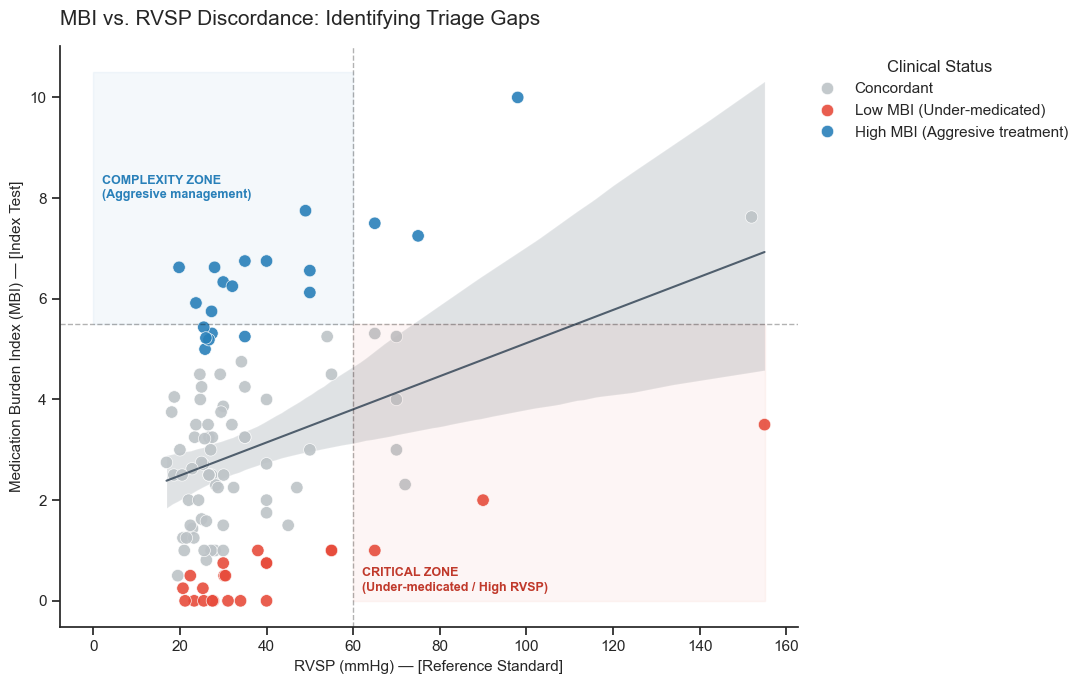

In [37]:
# MBI vs RVSP discordance on native valve status
# 1. We select the Native Data
native_df = df[df['Approach'] == 'Native'].copy()

# 2. Statistical Core: Residual Calculation
X = sm.add_constant(native_df['RVSP_Imputed'])
model = sm.OLS(native_df['MBI'], X).fit()
native_df['MBI_Residual'] = native_df['MBI'] - model.predict(X)

# We define Discordance Categories (Fixed threshold of 2.0)
def classify_discordance(res):
    if res > 2.0: return 'High MBI (Aggresive treatment)'
    if res < -2.0: return 'Low MBI (Under-medicated)'
    return 'Concordant'

native_df['Status'] = native_df['MBI_Residual'].apply(classify_discordance)

# 3. Visualization: Clean Regression with Marginal Distributions
plt.figure(figsize=(11, 7))
sns.set_style("ticks")

# We plot the regression line with a 95% Confidence Interval
sns.regplot(x='RVSP_Imputed', y='MBI', data=native_df, 
            scatter=False, color='#2c3e50', line_kws={"linewidth": 1.5, "alpha": 0.8})

# Scatterplot with uniform point size
ax = sns.scatterplot(x='RVSP_Imputed', y='MBI', hue='Status', 
                     palette={'Concordant': '#bdc3c7', 
                              'High MBI (Aggresive treatment)': '#2980b9', 
                              'Low MBI (Under-medicated)': '#e74c3c'},
                     data=native_df, s=80, alpha=0.9, edgecolor='white', linewidth=0.5)

# 4. Clinical Benchmarks (Thresholds)
plt.axhline(y=5.5, color='black', linestyle='--', linewidth=1, alpha=0.3)
plt.axvline(x=60, color='black', linestyle='--', linewidth=1, alpha=0.3)

# Annotating the "Safety Gap"
plt.fill_between([60, 155], 0, 5.5, color='#e74c3c', alpha=0.05) # Critical Quadrant
plt.text(62, 0.2, 'CRITICAL ZONE\n(Under-medicated / High RVSP)', color='#c0392b', fontsize=9, fontweight='bold')
plt.fill_between([0, 60], 5.5, 10.5, color='#2980b9', alpha=0.05) # Critical Quadrant
plt.text(2, 8, 'COMPLEXITY ZONE\n(Aggresive management)', color='#2980b9', fontsize=9, fontweight='bold')

# 5. Styling
plt.title('MBI vs. RVSP Discordance: Identifying Triage Gaps', fontsize=15, loc='left', pad=15)
plt.xlabel('RVSP (mmHg) — [Reference Standard]', fontsize=11)
plt.ylabel('Medication Burden Index (MBI) — [Index Test]', fontsize=11)
plt.legend(title='Clinical Status', frameon=False, bbox_to_anchor=(1, 1))

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
# Table to compare baseline characteristics between concordance status
# 1. We define the Discordant Cohorts (using the native_df from the previous step)
under_medicated = native_df[native_df['Status'] == 'Low MBI (Under-medicated)']
complex_masked = native_df[native_df['Status'] == 'High MBI (Aggresive treatment)']
concordant = native_df[native_df['Status'] == 'Concordant']

# 2. Rows for our comparison (following your Table 1 structure)
comparison_rows = [
    ('Age (years)', 'Age', 'mean'),
    ('Female (%)', 'Gender', 'pct'),
    ('Heart Rate (bpm)', 'Heart rate', 'mean'),
    ('Systolic BP (mmHg)', 'SBP R', 'mean'),
    ('Diastolic BP (mmHg)', 'DBP R', 'mean'),
    ('RVSP (mmHg)', 'RVSP_Imputed', 'mean'),
    ('LVEF (%)', 'LVEF_Score', 'mean'),
    ('MBI', 'MBI', 'mean')
]

discordance_table = pd.DataFrame()

# 3. We populate Columns
groups = [
    ('Under-medicated', under_medicated),
    ('Concordant', concordant),
    ('Aggresive treatment', complex_masked)
]

for name, subset_df in groups:
    n = len(subset_df)
    discordance_table[f"{name} (n={n})"] = [
        stats.format_stat(subset_df, col, is_pct) for _, col, is_pct in comparison_rows
    ]

discordance_table.index = [r[0] for r in comparison_rows]
print('Baseline characteristics by MBI/RVSP concordance status')
display(discordance_table)

Baseline characteristics by MBI/RVSP concordance status


,Under-medicated (n=22),Concordant (n=68),Aggresive treatment (n=20)
Age (years),39.5 ± 17.7,49.2 ± 15.5,51.6 ± 13.5
Female (%),50.0%,58.8%,85.0%
Heart Rate (bpm),80.9 ± 17.4,74.3 ± 13.3,78.2 ± 14.4
Systolic BP (mmHg),127.8 ± 23.7,126.3 ± 18.4,116.2 ± 15.3
Diastolic BP (mmHg),74.6 ± 18.8,77.9 ± 12.4,74.5 ± 11.0
RVSP (mmHg),42.2 ± 30.2,33.5 ± 19.8,39.5 ± 20.0
LVEF (%),57.0 ± 11.0,55.5 ± 11.8,54.0 ± 11.8
MBI,0.6 ± 0.8,2.8 ± 1.3,6.4 ± 1.2


Clinical Drivers of Discordance (Frequency Counts)
----------------------------------------
Under-medicated (n=22)
Aggresive treatment (n=20)


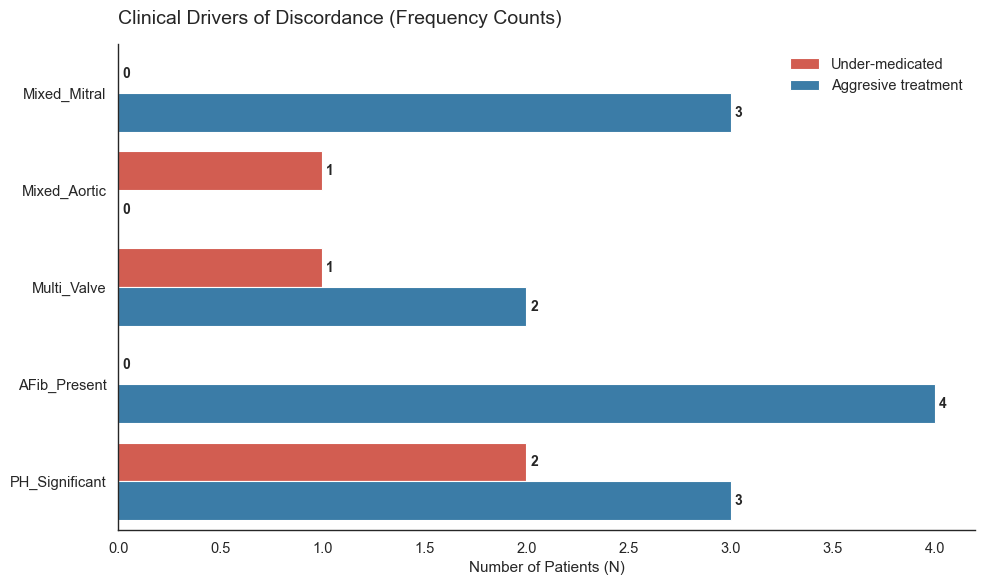

In [35]:
# Clinical drivers of discordance based on their MBI/RVSP relationship
# 1. Define the clinical markers we want to compare
pathology_markers = ['Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'AFib_Present', 'PH_Significant']

# 2. Prepare data for the frequency plot
# We compare the two discordant extremes
under_med = native_df[native_df['Status'] == 'Low MBI (Under-medicated)'][pathology_markers].sum()
complex_high = native_df[native_df['Status'] == 'High MBI (Aggresive treatment)'][pathology_markers].sum()

# Create a clean DataFrame for plotting
freq_df = pd.DataFrame({
    'Under-medicated': under_med,
    'Aggresive treatment': complex_high
}).reset_index().rename(columns={'index': 'Pathology'})

# 3. Visualization: Grouped Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Melt the dataframe for Seaborn
melted_freq = freq_df.melt(id_vars='Pathology', var_name='Group', value_name='Count')

ax = sns.barplot(data=melted_freq, y='Pathology', x='Count', hue='Group', 
                 palette={'Under-medicated': '#e74c3c', 
                          'Aggresive treatment': '#2980b9'})

# Add count labels to bars for transparency (essential for low n)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Clinical Drivers of Discordance (Frequency Counts)', fontsize=14, loc='left', pad=15)
plt.xlabel('Number of Patients (N)', fontsize=11)
plt.ylabel('')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
print('Clinical Drivers of Discordance (Frequency Counts)\n' + '-'*40)
print(f'Under-medicated (n={len(under_medicated)})')
print(f'Aggresive treatment (n={len(complex_masked)})')
plt.show()

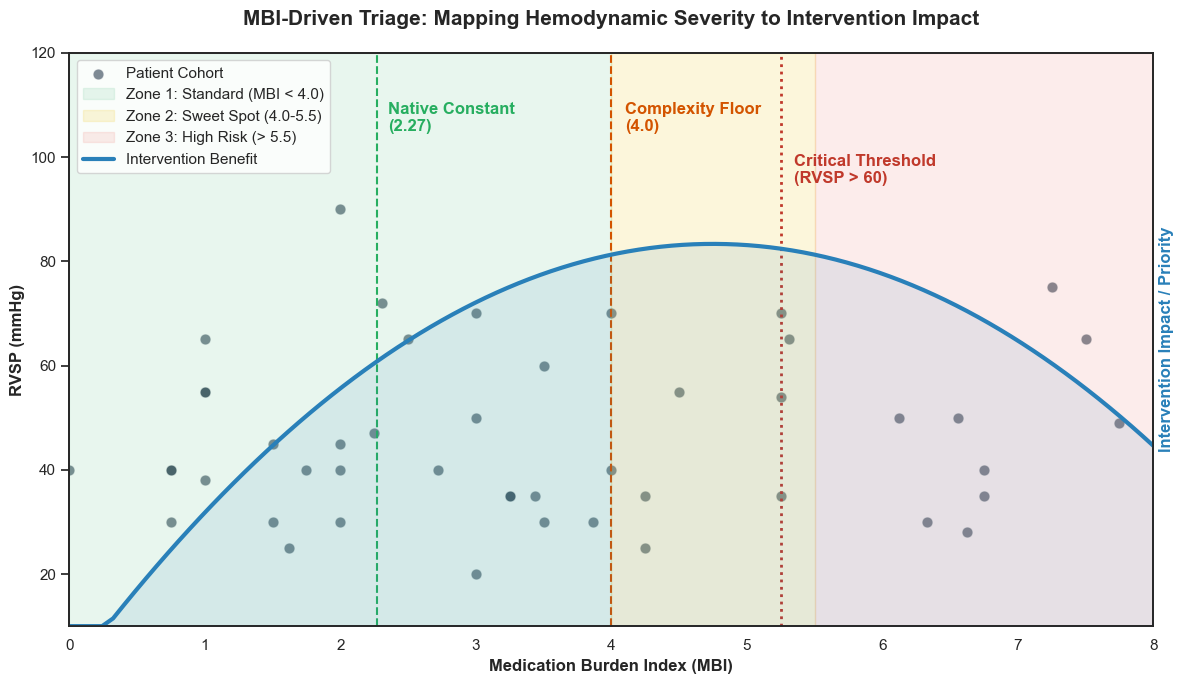

In [36]:
# 1. Plotting Configuration
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 7))

# PRIMARY AXIS: RVSP vs MBI Scatter
sns.scatterplot(data=df, x='MBI', y='RVSP', alpha=0.6, color='#2c3e50', s=60, ax=ax1, label='Patient Cohort')

# 2. Define Triage Zones (The Core Logic)
ax1.axvspan(0, 4.0, color='#27ae60', alpha=0.1, label='Zone 1: Standard (MBI < 4.0)')
ax1.axvspan(4.0, 5.5, color='#f1c40f', alpha=0.15, label='Zone 2: Sweet Spot (4.0-5.5)')
ax1.axvspan(5.5, 8.0, color='#e74c3c', alpha=0.1, label='Zone 3: High Risk (> 5.5)')

# 3. Clinical Threshold Markers
# Native Constant (2.27)
ax1.axvline(2.27, color='#27ae60', linestyle='--', linewidth=1.5)
ax1.text(2.35, 105, 'Native Constant\n(2.27)', color='#27ae60', fontweight='bold')

# Complexity Floor (4.0)
ax1.axvline(4.0, color='#d35400', linestyle='--', linewidth=1.5)
ax1.text(4.1, 105, 'Complexity Floor\n(4.0)', color='#d35400', fontweight='bold')

# ROC-Derived Critical Threshold (5.25)
ax1.axvline(5.25, color='#c0392b', linestyle=':', linewidth=2)
ax1.text(5.35, 95, 'Critical Threshold\n(RVSP > 60)', color='#c0392b', fontweight='bold')

# 4. SECONDARY AXIS: The "U-Shape" Benefit Curve
ax2 = ax1.twinx()
x_curve = np.linspace(0, 8, 100)
# Parabolic benefit centered on the Sweet Spot (~4.75)
benefit_curve = -0.5 * (x_curve - 4.75)**2 + 10 
benefit_curve = np.clip(benefit_curve, 0, 10)

ax2.plot(x_curve, benefit_curve, color='#2980b9', linewidth=3, label='Intervention Benefit')
ax2.fill_between(x_curve, 0, benefit_curve, color='#2980b9', alpha=0.1)

# 5. Styling & Labels
ax1.set_xlabel('Medication Burden Index (MBI)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RVSP (mmHg)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Intervention Impact / Priority', fontsize=12, fontweight='bold', color='#2980b9')
plt.title('MBI-Driven Triage: Mapping Hemodynamic Severity to Intervention Impact', fontsize=15, pad=20, fontweight='bold')

# Legend and limits
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)
ax1.set_xlim(0, 8)
ax1.set_ylim(10, 120)
ax2.set_ylim(0, 15)
ax2.set_yticks([]) # Qualitative axis

plt.tight_layout()
plt.show()

---

In [ ]:
# Generates LaTeX code with professional formatting
latex_table = table_one.to_latex(
    index=True,
    column_format='p{4cm}cccc|c', # Adjusts the width of the first column and aligns the rest
    escape=False,                  # Allows for ± to be rendered correctly
    bold_rows=False,
    caption="Baseline Characteristics and Hemodynamic Profile Stratified by MBI Triage Zones",
    label="tab:baseline_characteristics",
    position="htbp",
    # column_format="lcccc|c"        # 'l' for variable, 'c' for zones, '|c' to separate p-value
)

# Booktabs style
latex_table = latex_table.replace('\\toprule', '\\hline\\hline')
latex_table = latex_table.replace('\\midrule', '\\hline')
latex_table = latex_table.replace('\\bottomrule', '\\hline\\hline')

print("--- COPIA ESTE CÓDIGO PARA OVERLEAF ---")
print(latex_table)

--- COPIA ESTE CÓDIGO PARA OVERLEAF ---
\begin{table}[htbp]
\caption{Baseline Characteristics and Hemodynamic Profile Stratified by MBI Triage Zones}
\label{tab:baseline_characteristics}
\begin{tabular}{p{4cm}cccc|c}
\hline\hline
 & All Patients (N=152) & Zone 1 (n=113) & Zone 2 (n=22) & Zone 3 (n=17) \\
\hline
Age (years) & 47.1 ± 15.7 & 45.3 ± 16.4 & 54.6 ± 10.1 & 49.8 ± 13.4 \\
Female (%) & 64.5% & 58.4% & 77.3% & 88.2% \\
Heart Rate (bpm) & 76.6 ± 14.1 & 76.2 ± 14.2 & 79.5 ± 14.2 & 75.8 ± 14.1 \\
Systolic BP (mmHg) & 124.6 ± 18.7 & 127.4 ± 18.7 & 113.6 ± 17.0 & 120.9 ± 15.2 \\
Diastolic BP (mmHg) & 76.7 ± 12.5 & 77.7 ± 12.9 & 72.9 ± 10.3 & 75.2 ± 11.6 \\
RVSP (mmHg) & 33.4 ± 20.3 & 31.0 ± 17.1 & 34.6 ± 16.9 & 47.7 ± 34.7 \\
LVEF (%) & 56.6 ± 10.1 & 57.6 ± 9.1 & 52.7 ± 13.7 & 55.0 ± 10.3 \\
\hline\hline
\end{tabular}
\end{table}



In [ ]:
# Generates LaTeX code with professional formatting
latex_table = table_two.to_latex(
    index=True,
    column_format='p{4cm}cccc|c', # Adjusts the width of the first column and aligns the rest
    escape=False,                  # Allows for ± to be rendered correctly
    bold_rows=False,
    caption="Baseline Characteristics and Hemodynamic Profile Stratified by MBI Triage Zones",
    label="tab:baseline_characteristics",
    position="htbp",
    # column_format="lcccc|c"        # 'l' for variable, 'c' for zones, '|c' to separate p-value
)

# Booktabs style
latex_table = latex_table.replace('\\toprule', '\\hline\\hline')
latex_table = latex_table.replace('\\midrule', '\\hline')
latex_table = latex_table.replace('\\bottomrule', '\\hline\\hline')

print("--- COPIA ESTE CÓDIGO PARA OVERLEAF ---")
print(latex_table)

--- COPIA ESTE CÓDIGO PARA OVERLEAF ---
\begin{table}[htbp]
\caption{Baseline Characteristics and Hemodynamic Profile Stratified by MBI Triage Zones}
\label{tab:baseline_characteristics}
\begin{tabular}{p{4cm}cccc|c}
\hline\hline
 & All Patients (N=152) & Native (n=110) & Percutaneous (n=17) & Surgical (n=25) \\
\hline
Age (years) & 47.1 ± 15.7 & 47.7 ± 16.0 & 42.9 ± 14.4 & 47.4 ± 14.9 \\
Female (%) & 64.5% & 61.8% & 88.2% & 60.0% \\
Heart Rate (bpm) & 76.6 ± 14.1 & 76.3 ± 14.5 & 71.2 ± 13.2 & 81.5 ± 11.8 \\
Systolic BP (mmHg) & 124.6 ± 18.7 & 124.8 ± 19.4 & 123.8 ± 18.2 & 124.7 ± 16.3 \\
Diastolic BP (mmHg) & 76.7 ± 12.5 & 76.6 ± 13.6 & 75.7 ± 9.7 & 77.7 ± 8.2 \\
RVSP (mmHg) & 33.4 ± 20.3 & 35.8 ± 22.6 & 31.8 ± 13.1 & 23.5 ± 3.9 \\
LVEF (%) & 56.6 ± 10.1 & 55.5 ± 11.6 & 58.2 ± 3.9 & 60.0 ± 0.0 \\
MBI & 2.9 ± 2.1 & 3.0 ± 2.2 & 3.2 ± 2.6 & 1.9 ± 1.4 \\
\hline\hline
\end{tabular}
\end{table}



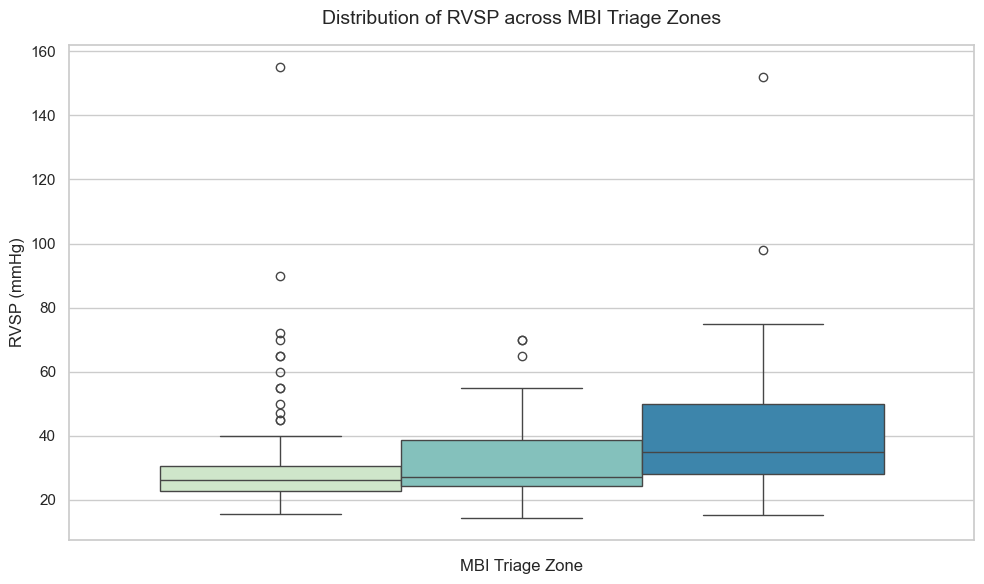

In [ ]:
# Boxplot: Distribution of RVSP across MBI triage zones
# Base styling
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We create the Boxplot
ax = sns.boxplot(hue='MBI_Zone', y='RVSP_Imputed', data=df, 
                 palette="GnBu", showfliers=True, legend=False)

# Titles and labels
plt.title('Distribution of RVSP across MBI Triage Zones', fontsize=14, pad=15)
plt.xlabel('MBI Triage Zone', fontsize=12)
plt.ylabel('RVSP (mmHg)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# We set a discordance threshold (e.g., a difference of 1.5 or 2 points on the MBI scale)
threshold = 2
y_var = 'MBI'
res_col = f'{y_var}_Residual'

# We identify the 'Under-medicated' (Actual < Predicted) 
# These are the ones with large NEGATIVE residuals
under_medicated = mbi_mismatch[mbi_mismatch[res_col] < -threshold].copy()
under_medicated['Clinical_Status'] = 'Under-medicated (Gap)'

# We identify the 'Unexpectedly High MBI' (Actual > Predicted)
# These are the ones with large POSITIVE residuals
high_mbi = mbi_mismatch[mbi_mismatch[res_col] > threshold].copy()
high_mbi['Clinical_Status'] = 'High MBI (Complex)'

# We merge and select clinical columns for review
discordant_cases = pd.concat([under_medicated, high_mbi])
count_under = (discordant_cases['Clinical_Status'] == 'Under-medicated (Gap)').sum()
count_high = (discordant_cases['Clinical_Status'] == 'High MBI (Complex)').sum()

# We also set the MBI zones too to see any difference related per strata
zone_breakdown = discordant_cases.groupby(['MBI_Zone', 'Clinical_Status'], observed=True).size().unstack(fill_value=0)

# We use the columns you were inspecting, plus the calculated residual
cols_to_review = [
    'Approach', 'MBI_Zone', 'Pre-procedure diagnosis', 'Post-procedure diagnosis', 'Medications',
    'Sev_MS','Sev_MR', 'Sev_AS', 'Sev_AR', 'Mixed_Mitral', 'Mixed_Aortic', 'Multi_Valve', 'Sev_PH', 'AFib_Present',
    'RVSP_Imputed', 'LVEF_Score', 'MBI', res_col, 'Clinical_Status'
]

# We sort by the absolute size of the error to see the most 'confusing' cases first
discordance_table = discordant_cases[cols_to_review].sort_values(by=res_col)

print(f"\nOUTLIER SUMMARY (Threshold |Residual| > {threshold})")
print("-" * 60)
print(f"Total Discordant Patients: {len(discordant_cases)} ({(len(discordant_cases)/157*100):.1f}%)")
print(f"  - Under-medicated:   {count_under} ({(len(under_medicated)/157*100):.1f}%)")
print(f"  - High MBI (Complex): {count_high} ({(len(high_mbi)/157*100):.1f}%)\n")


OUTLIER SUMMARY (Threshold |Residual| > 2)
------------------------------------------------------------
Total Discordant Patients: 39 (24.8%)
  - Under-medicated:   21 (13.4%)
  - High MBI (Complex): 18 (11.5%)



In [ ]:
cols_to_review = [
    'Approach', 'MBI_Zone', 'Pre-procedure diagnosis', 'Post-procedure diagnosis', 'Medications',
    'RVSP_Imputed', 'LVEF_Score', 'MBI', res_col
]

under_table = under_medicated[cols_to_review].sort_values(by=res_col)
over_table = high_mbi[cols_to_review].sort_values(by=res_col)

print(f" Under-medicated (Gap) cases identified (Threshold > {threshold})\n" + '-'*60)
print(under_table)

 Under-medicated (Gap) cases identified (Threshold > 2)
------------------------------------------------------------
         Approach        MBI_Zone  \
ID                                  
147        Native  Zone 1 (n=113)   
82         Native  Zone 1 (n=113)   
128        Native  Zone 1 (n=113)   
44         Native  Zone 1 (n=113)   
38   Percutaneous  Zone 1 (n=113)   
49         Native  Zone 1 (n=113)   
16         Native  Zone 1 (n=113)   
91   Percutaneous  Zone 1 (n=113)   
75         Native  Zone 1 (n=113)   
77         Native  Zone 1 (n=113)   
130        Native  Zone 1 (n=113)   
148        Native  Zone 1 (n=113)   
83         Native  Zone 1 (n=113)   
41         Native  Zone 1 (n=113)   
35         Native  Zone 1 (n=113)   
135        Native  Zone 1 (n=113)   
115        Native  Zone 1 (n=113)   
111        Native  Zone 1 (n=113)   
14   Percutaneous  Zone 1 (n=113)   
63         Native  Zone 1 (n=113)   
107        Native  Zone 1 (n=113)   

                               

In [ ]:
print(f" High MBI (Complex) cases identified (Threshold > {threshold})\n" + '-'*60)
print(over_table)

 High MBI (Complex) cases identified (Threshold > 2)
------------------------------------------------------------
         Approach       MBI_Zone  \
ID                                 
32         Native  Zone 2 (n=16)   
28         Native  Zone 2 (n=16)   
27         Native  Zone 2 (n=16)   
113        Native   Zone 3 (n=6)   
67         Native  Zone 2 (n=16)   
122        Native  Zone 4 (n=17)   
108        Native  Zone 4 (n=17)   
45       Surgical  Zone 2 (n=16)   
142        Native  Zone 4 (n=17)   
114        Native  Zone 4 (n=17)   
73         Native  Zone 4 (n=17)   
62         Native  Zone 4 (n=17)   
138        Native  Zone 4 (n=17)   
140        Native  Zone 4 (n=17)   
105        Native  Zone 4 (n=17)   
90   Percutaneous  Zone 4 (n=17)   
132        Native  Zone 4 (n=17)   
24   Percutaneous  Zone 4 (n=17)   

                               Pre-procedure diagnosis  \
ID                                                       
32                       Secundum atrial septal d

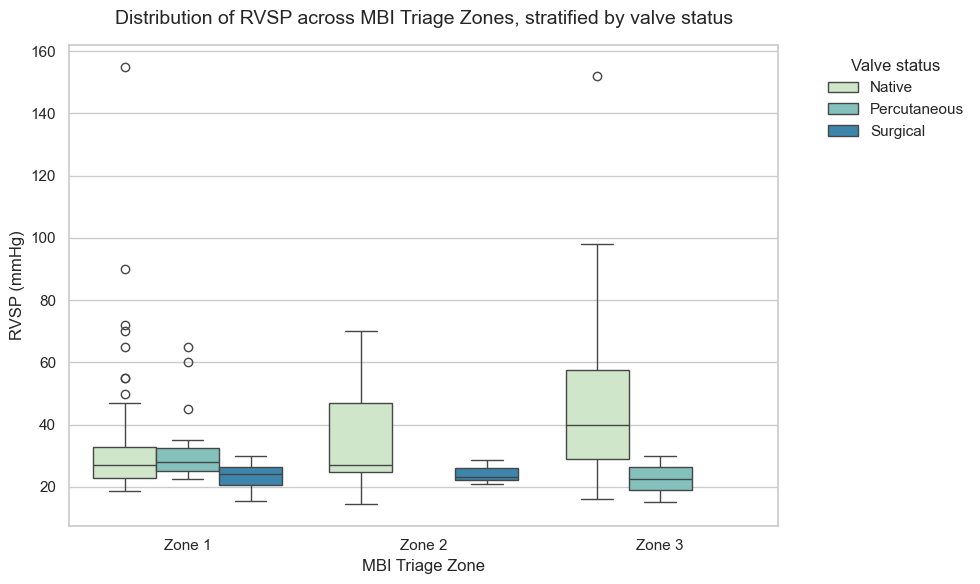

In [ ]:
# Boxplot: Distribution of RVSP across MBI triage zones, stratified by valve status
# Base styling
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We create the Boxplot
ax = sns.boxplot(x='MBI_Zone', y='RVSP_Imputed', hue='Approach', data=df, 
                 palette="GnBu", showfliers=True)

# Titles and labels
plt.title('Distribution of RVSP across MBI Triage Zones, stratified by valve status', fontsize=14, pad=15)
plt.xlabel('MBI Triage Zone', fontsize=12)
plt.ylabel('RVSP (mmHg)', fontsize=12)

plt.legend(title='Valve status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()